# Insurance Risk Analytics — Exploratory Data Analysis

**Dataset:** `MachineLearningRating_v3.csv`  |  **Delimiter:** `|`

---
### Notebook Sections
1. Setup & Data Loading
2. Dtype Corrections
3. Data Quality Assessment
4. Univariate Analysis
5. Bivariate / Multivariate Analysis
6. Geographic Trends
7. Outlier Detection


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
DATA_PATH = '../data/MachineLearningRating_v3.csv'
df = pd.read_csv(DATA_PATH, sep='|', low_memory=False, on_bad_lines='skip')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1000098, 52)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.00",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,"2,597.00",130.00,S/D,4.00,6/2002,"119,300.00",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.93,0.00
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.00",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,"2,597.00",130.00,S/D,4.00,6/2002,"119,300.00",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.93,0.00
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.00",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,"2,597.00",130.00,S/D,4.00,6/2002,"119,300.00",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.00,0.00


## 2. Dtype Corrections

In [3]:
# Date columns
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])
df['VehicleIntroDate']  = pd.to_datetime(df['VehicleIntroDate'], errors='coerce')

# Numeric stored as object
df['CapitalOutstanding'] = pd.to_numeric(df['CapitalOutstanding'], errors='coerce')

# PostalCode as identifier
df['PostalCode'] = df['PostalCode'].astype(str)

# Low-cardinality -> category
low_card = [
    'LegalType','Title','Language','Bank','AccountType','MaritalStatus',
    'Gender','Country','Province','MainCrestaZone','SubCrestaZone',
    'ItemType','VehicleType','bodytype','AlarmImmobiliser','TrackingDevice',
    'NewVehicle','WrittenOff','Rebuilt','Converted','CrossBorder',
    'TermFrequency','CoverCategory','CoverType','CoverGroup','Section',
    'Product','StatutoryClass','StatutoryRiskType','ExcessSelected','Citizenship'
]
for col in low_card:
    df[col] = df[col].astype('category')

# Drop zero-variance and 100%-missing columns
zero_var = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
drop_cols = list(set(zero_var + ['NumberOfVehiclesInFleet']))
df.drop(columns=drop_cols, inplace=True)

# Negative value flags
df['flag_negative_premium'] = df['TotalPremium'] < 0
df['flag_negative_claims']  = df['TotalClaims']  < 0

print(f'Shape after corrections: {df.shape}')
print(df.dtypes.value_counts())

Shape after corrections: (1000098, 47)
float64           11
category           5
int64              3
object             3
bool               3
datetime64[ns]     2
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64


## 3. Data Quality Assessment

In [4]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mdf = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
mdf = mdf[mdf['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)

strategy = {
    'NumberOfVehiclesInFleet': 'Dropped — 100% missing',
    'CrossBorder':             'Dropped — 99.9% missing + zero variance',
    'CustomValueEstimate':     'Keep — only applicable to specific cover types',
    'WrittenOff':              'Keep — applicable subset; flag NaN separately',
    'Rebuilt':                 'Keep — applicable subset; flag NaN separately',
    'Converted':               'Keep — applicable subset; flag NaN separately',
    'NewVehicle':              'Impute with mode or label Unknown',
    'Bank':                    'Impute with mode or label Unknown',
    'AccountType':             'Impute with mode or label Unknown',
    'Gender':                  'Map NaN to Not specified',
    'MaritalStatus':           'Map NaN to Not specified',
}
mdf['Handling_Strategy'] = mdf.index.map(strategy).fillna('Drop row — <0.1% missing')
display(mdf)

,Missing_Count,Missing_%,Handling_Strategy
CustomValueEstimate,779642,77.96,Keep — only applicable to specific cover types
Rebuilt,641901,64.18,Keep — applicable subset; flag NaN separately
WrittenOff,641901,64.18,Keep — applicable subset; flag NaN separately
Converted,641901,64.18,Keep — applicable subset; flag NaN separately
NewVehicle,153295,15.33,Impute with mode or label Unknown
Bank,145961,14.59,Impute with mode or label Unknown
AccountType,40232,4.02,Impute with mode or label Unknown
Gender,9536,0.95,Map NaN to Not specified
MaritalStatus,8259,0.83,Map NaN to Not specified
mmcode,552,0.06,Drop row — <0.1% missing


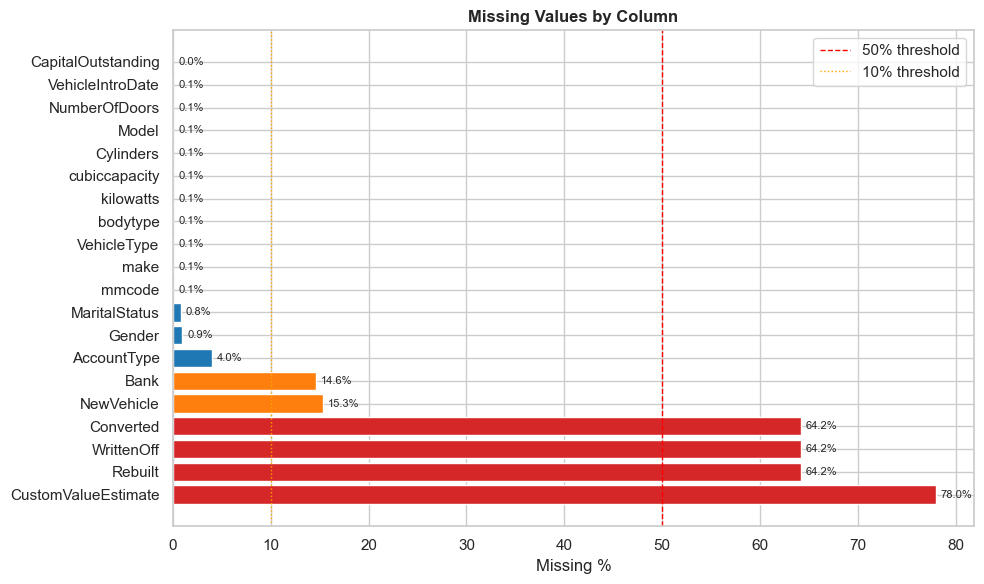

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if p > 50 else '#ff7f0e' if p > 10 else '#1f77b4'
          for p in mdf['Missing_%']]
bars = ax.barh(mdf.index, mdf['Missing_%'], color=colors, edgecolor='white')
ax.axvline(50,  color='red',    linestyle='--', lw=1, label='50% threshold')
ax.axvline(10,  color='orange', linestyle=':',  lw=1, label='10% threshold')
for bar, pct in zip(bars, mdf['Missing_%']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Univariate Analysis
### 4a. Numerical Columns — Histograms

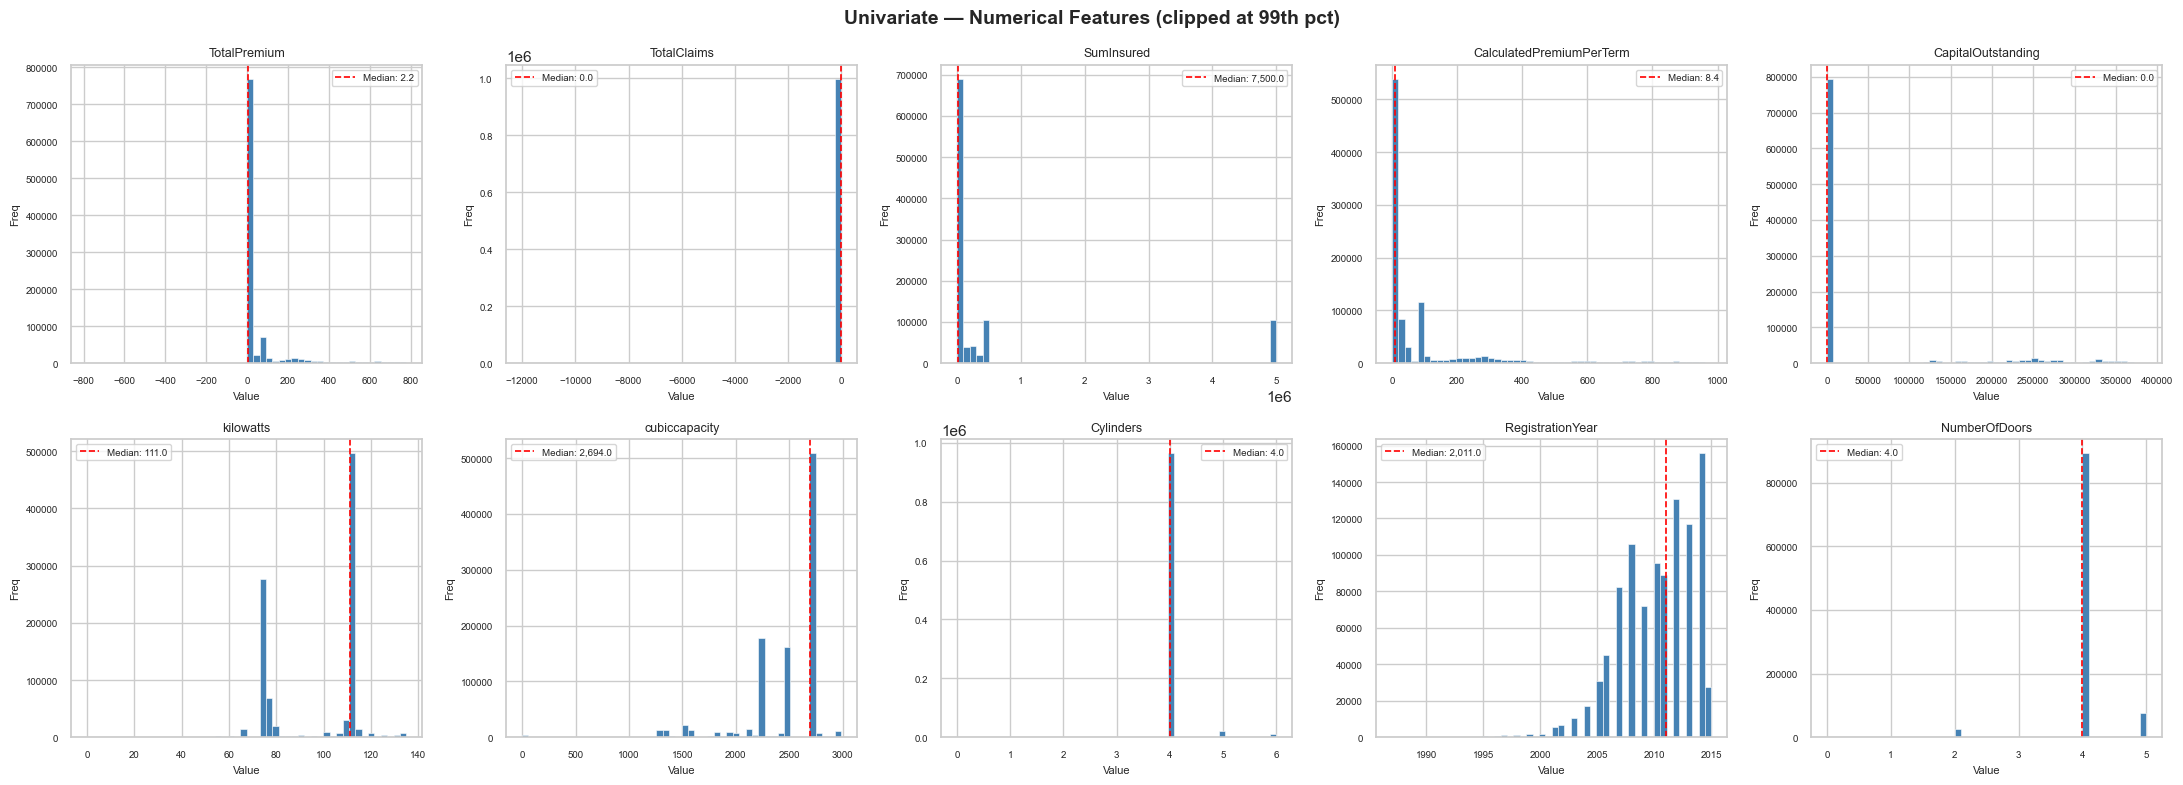

In [6]:
num_cols = [
    'TotalPremium','TotalClaims','SumInsured','CalculatedPremiumPerTerm',
    'CapitalOutstanding','kilowatts','cubiccapacity','Cylinders',
    'RegistrationYear','NumberOfDoors'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Univariate — Numerical Features (clipped at 99th pct)', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    data = df[col].dropna()
    clip_val = data.quantile(0.99)
    clipped  = data[data <= clip_val]
    ax.hist(clipped, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(data.median(), color='red', linestyle='--', lw=1.2,
               label=f'Median: {data.median():,.1f}')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Freq',  fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

### 4b. Categorical Columns — Bar Charts

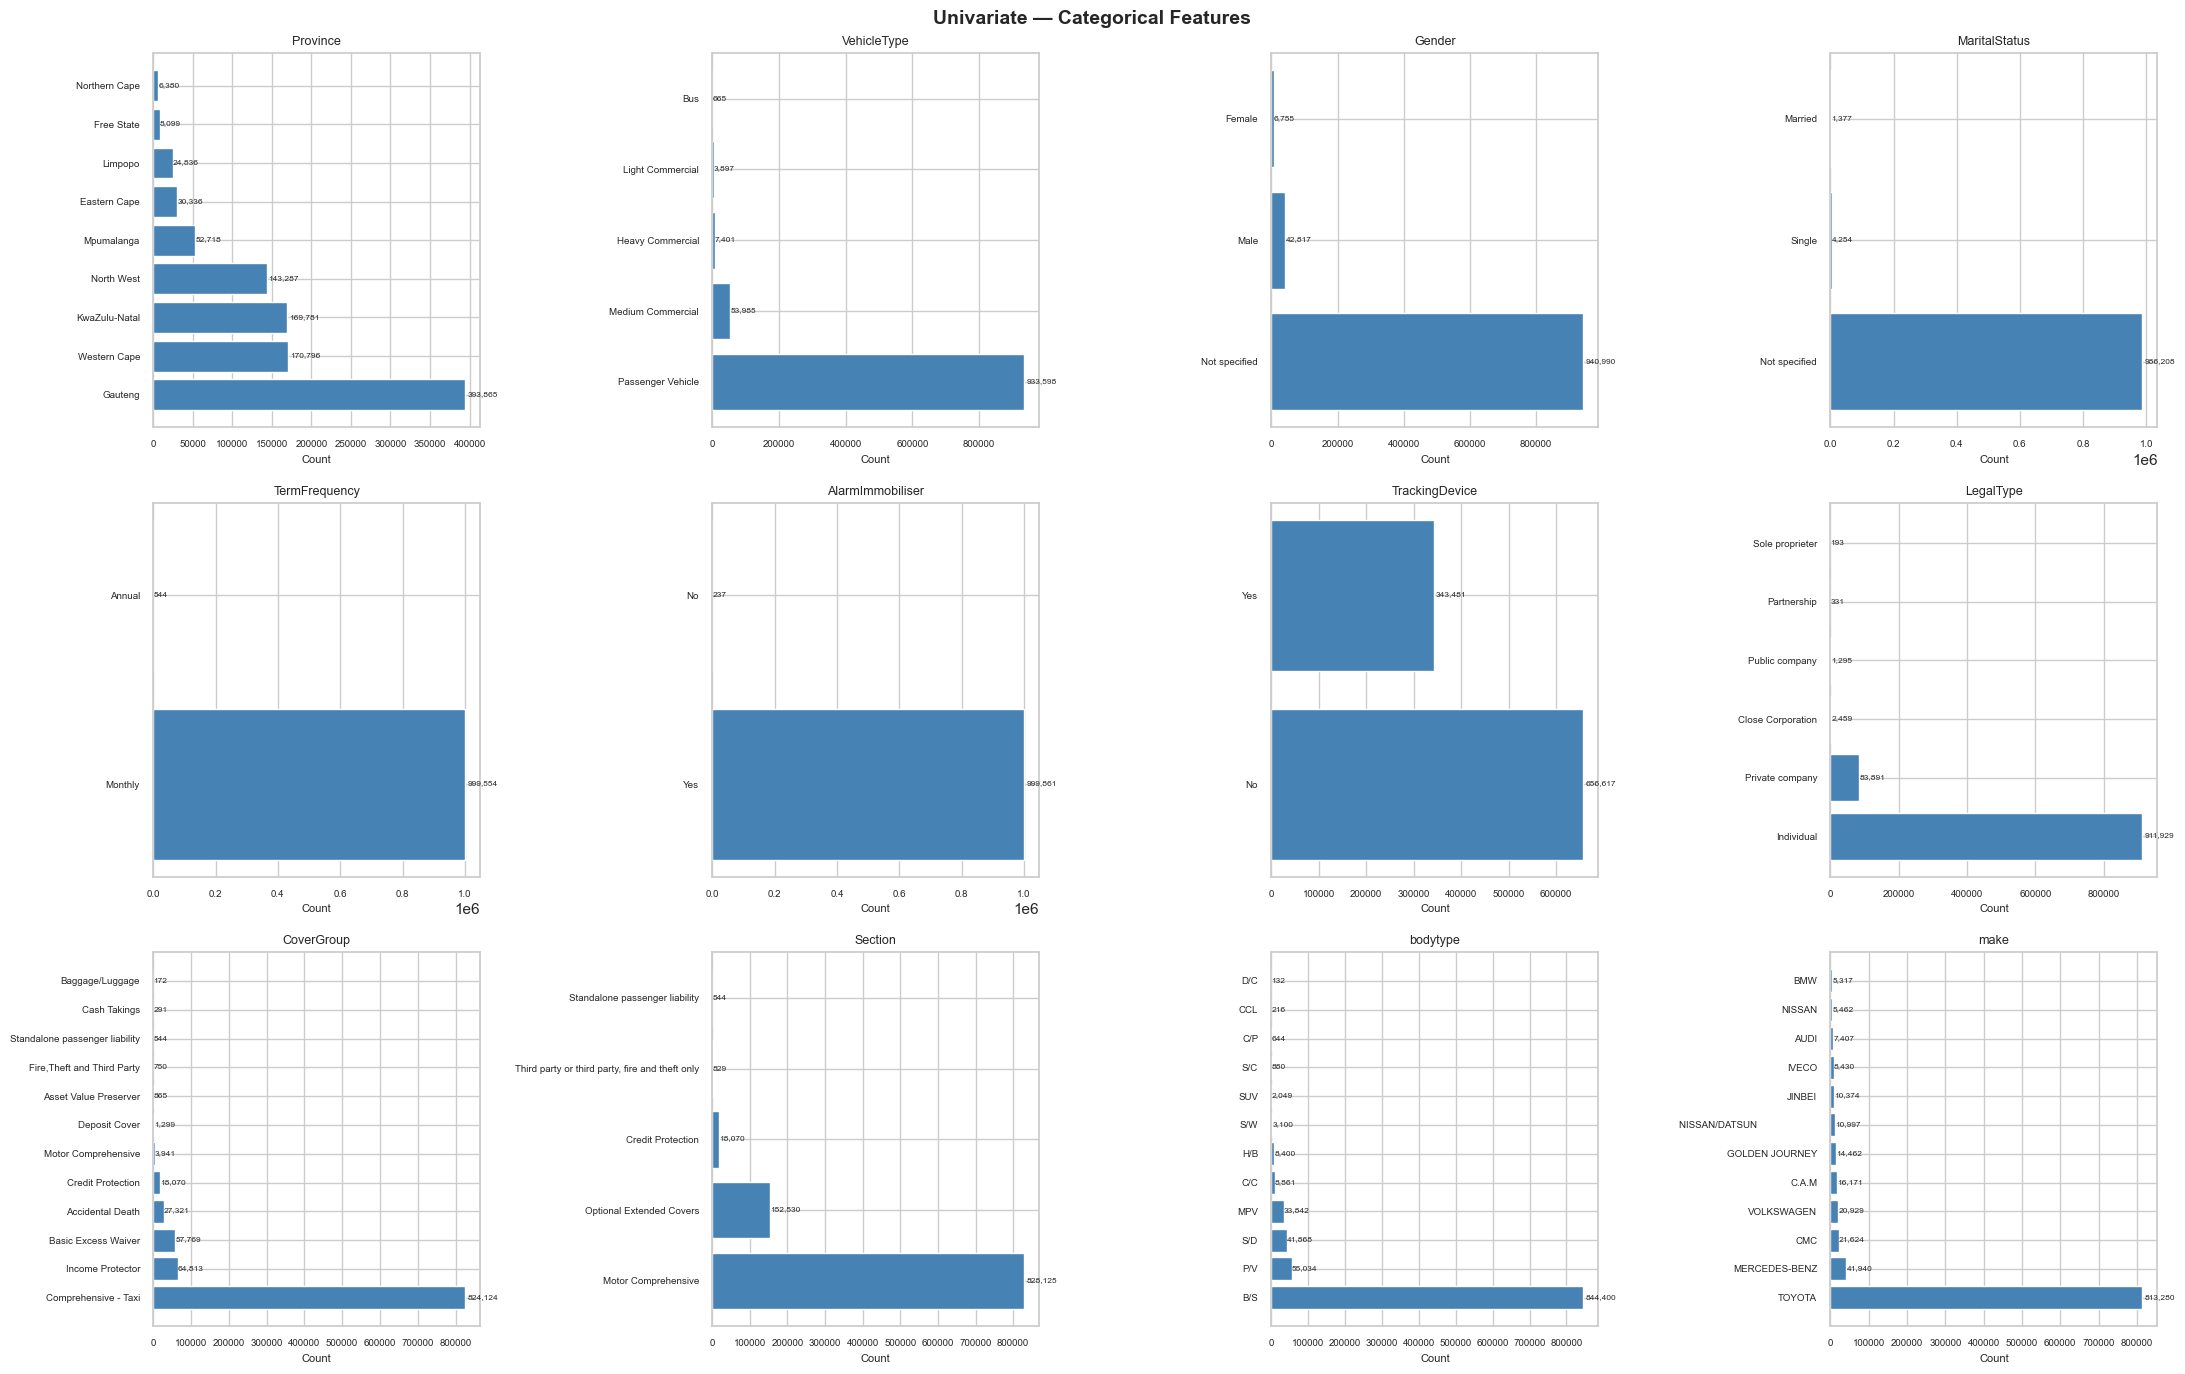

In [7]:
cat_plot = [
    'Province','VehicleType','Gender','MaritalStatus',
    'TermFrequency','AlarmImmobiliser','TrackingDevice',
    'LegalType','CoverGroup','Section','bodytype','make'
]

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
fig.suptitle('Univariate — Categorical Features', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_plot):
    counts = df[col].value_counts().head(12)
    ax.barh(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)
    for i, v in enumerate(counts.values):
        ax.text(v * 1.01, i, f'{v:,}', va='center', fontsize=6)

plt.tight_layout()
plt.show()

## 5. Bivariate / Multivariate Analysis

### 5a. TotalPremium vs TotalClaims — Scatter by Postal Zone

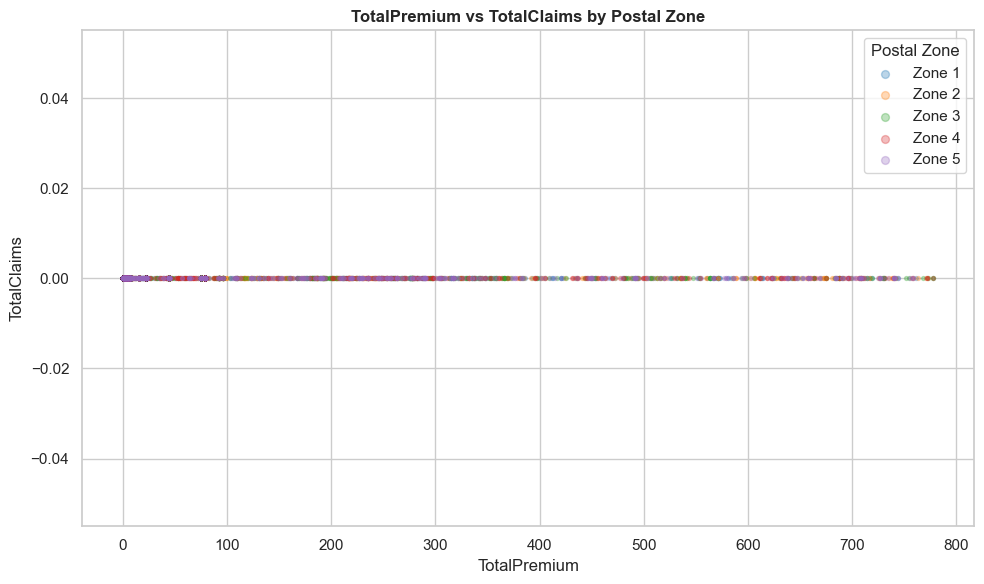

In [8]:
sample = df[['TotalPremium','TotalClaims','PostalCode']].dropna().copy()
p99_prem  = sample['TotalPremium'].quantile(0.99)
p99_claim = sample['TotalClaims'].quantile(0.99)
sample = sample[
    (sample['TotalPremium'] <= p99_prem) &
    (sample['TotalClaims']  <= p99_claim) &
    (sample['TotalPremium'] >= 0) &
    (sample['TotalClaims']  >= 0)
]

sample['PostalCode_num'] = pd.to_numeric(sample['PostalCode'], errors='coerce')
sample['PostalBucket']  = pd.cut(
    sample['PostalCode_num'], bins=5,
    labels=['Zone 1','Zone 2','Zone 3','Zone 4','Zone 5']
)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('tab10', 5)
for i, zone in enumerate(['Zone 1','Zone 2','Zone 3','Zone 4','Zone 5']):
    sub = sample[sample['PostalBucket'] == zone]
    sub = sub.sample(min(2000, len(sub)), random_state=42)
    ax.scatter(sub['TotalPremium'], sub['TotalClaims'],
               alpha=0.3, s=8, color=palette[i], label=zone)

ax.set_xlabel('TotalPremium')
ax.set_ylabel('TotalClaims')
ax.set_title('TotalPremium vs TotalClaims by Postal Zone', fontweight='bold')
ax.legend(title='Postal Zone', markerscale=2)
plt.tight_layout()
plt.show()

### 5b. Aggregated Mean Premium and Claims by PostalCode (Top 20)

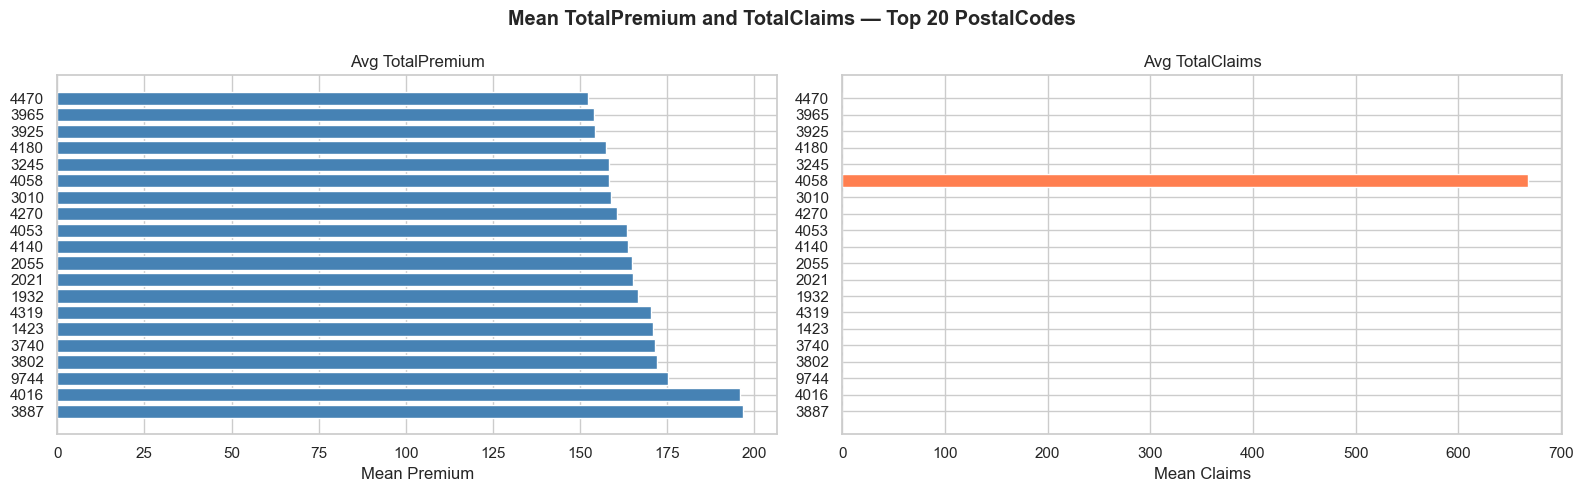

In [9]:
postal_agg = (
    df.groupby('PostalCode')[['TotalPremium','TotalClaims']]
      .mean()
      .sort_values('TotalPremium', ascending=False)
      .head(20)
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Mean TotalPremium and TotalClaims — Top 20 PostalCodes', fontweight='bold')

axes[0].barh(postal_agg['PostalCode'], postal_agg['TotalPremium'], color='steelblue')
axes[0].set_title('Avg TotalPremium')
axes[0].set_xlabel('Mean Premium')

axes[1].barh(postal_agg['PostalCode'], postal_agg['TotalClaims'], color='coral')
axes[1].set_title('Avg TotalClaims')
axes[1].set_xlabel('Mean Claims')

plt.tight_layout()
plt.show()

### 5c. Correlation Matrix — Key Numerical Features

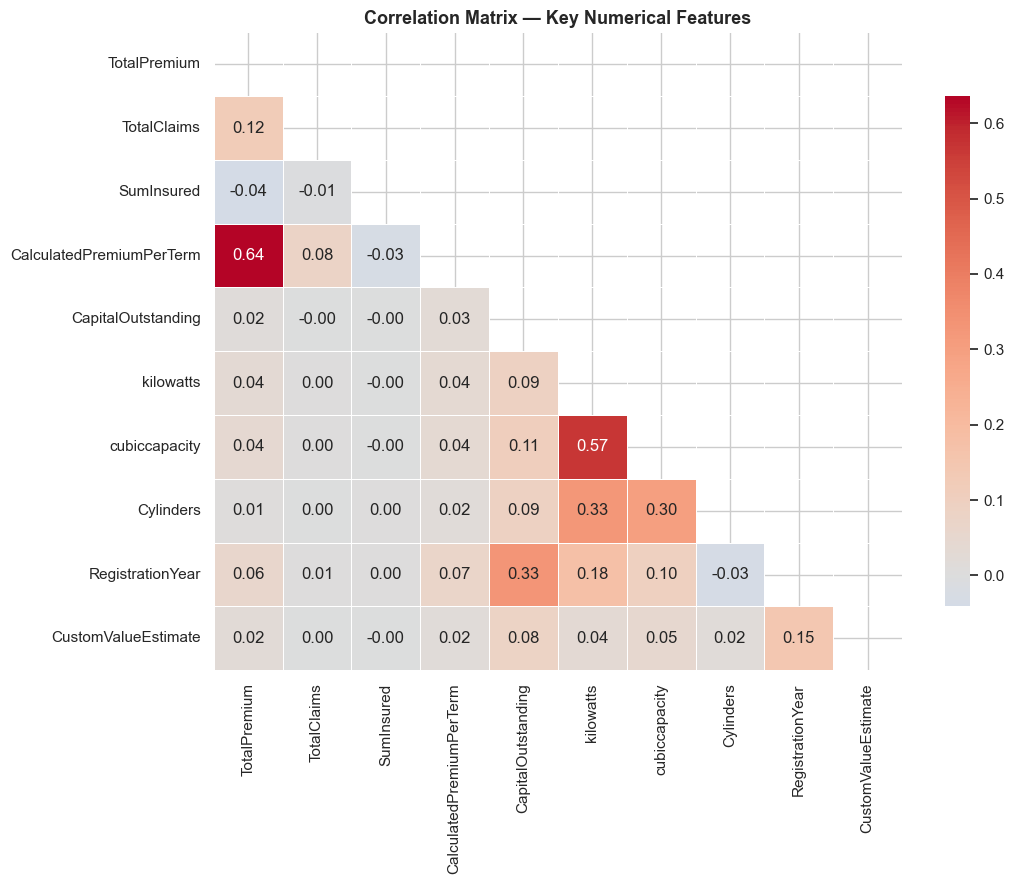

In [10]:
corr_cols = [
    'TotalPremium','TotalClaims','SumInsured','CalculatedPremiumPerTerm',
    'CapitalOutstanding','kilowatts','cubiccapacity','Cylinders',
    'RegistrationYear','CustomValueEstimate'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5d. Pair Plot — Premium, Claims, SumInsured by VehicleType

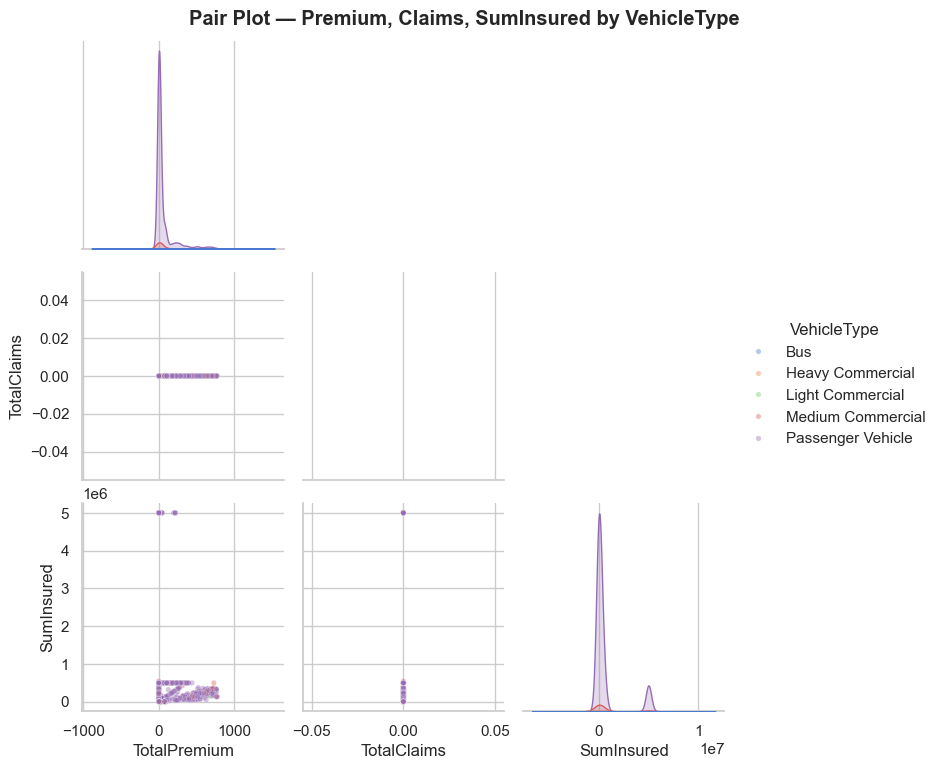

In [11]:
pp_cols = ['TotalPremium','TotalClaims','SumInsured']
pp_data = df[pp_cols + ['VehicleType']].dropna().copy()
for c in pp_cols:
    pp_data = pp_data[pp_data[c] <= pp_data[c].quantile(0.99)]
pp_data = pp_data.sample(5000, random_state=42)

g = sns.pairplot(
    pp_data, vars=pp_cols, hue='VehicleType',
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde', corner=True
)
g.fig.suptitle('Pair Plot — Premium, Claims, SumInsured by VehicleType',
               y=1.02, fontweight='bold')
plt.show()

## 6. Geographic Trends — Province Level

### 6a. Average TotalPremium and TotalClaims by Province

TotalPremium                TotalClaims               
                      mean median   count        mean median   count
Province                                                            
Eastern Cape         70.55   2.44   30336       44.71   0.00   30336
Free State           64.37   3.59    8099       43.82   0.00    8099
Gauteng              61.07   2.15  393865       74.63   0.00  393865
KwaZulu-Natal        77.80   2.68  169781       84.23   0.00  169781
Limpopo              61.90   3.17   24836       40.93   0.00   24836
Mpumalanga           53.80   1.81   52718       38.79   0.00   52718
North West           52.28   1.83  143287       41.32   0.00  143287
Northern Cape        49.62   1.50    6380       14.03   0.00    6380
Western Cape         57.42   1.72  170796       60.83   0.00  170796

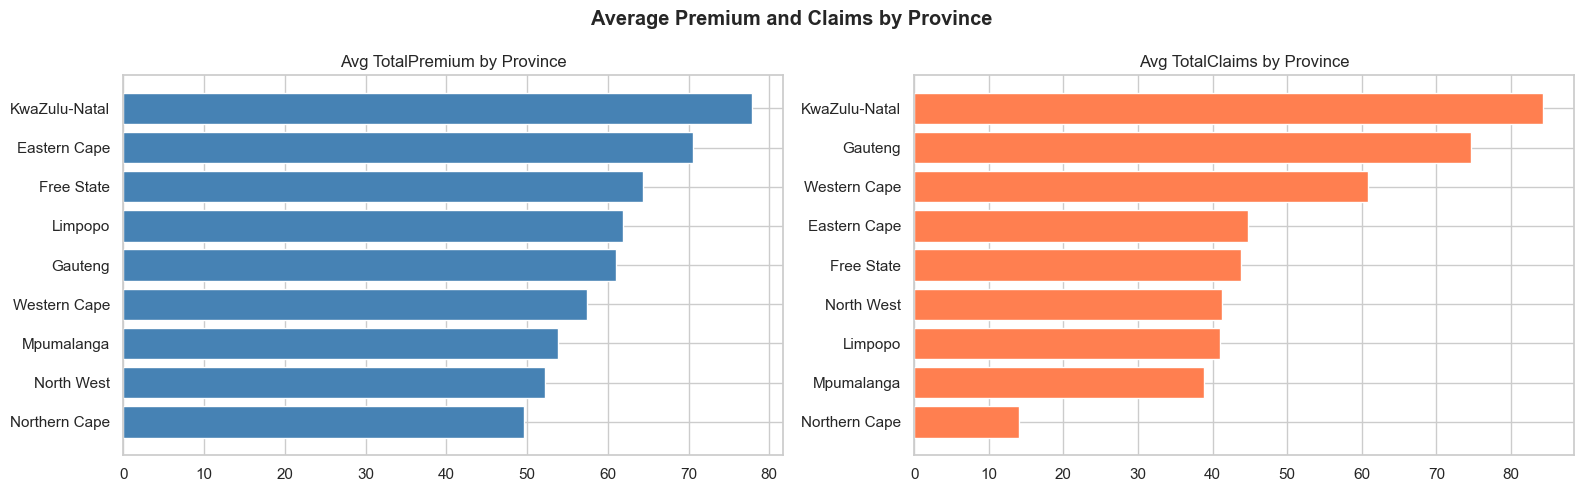

In [12]:
prov_agg = (
    df.groupby('Province')[['TotalPremium','TotalClaims']]
      .agg(['mean','median','count'])
      .round(2)
)
display(prov_agg)

prov_mean = df.groupby('Province')[['TotalPremium','TotalClaims']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Average Premium and Claims by Province', fontweight='bold')

prov_s1 = prov_mean.sort_values('TotalPremium', ascending=True)
axes[0].barh(prov_s1['Province'].astype(str), prov_s1['TotalPremium'], color='steelblue')
axes[0].set_title('Avg TotalPremium by Province')

prov_s2 = prov_mean.sort_values('TotalClaims', ascending=True)
axes[1].barh(prov_s2['Province'].astype(str), prov_s2['TotalClaims'], color='coral')
axes[1].set_title('Avg TotalClaims by Province')

plt.tight_layout()
plt.show()

### 6b. Top Cover Types by Province — Heatmap

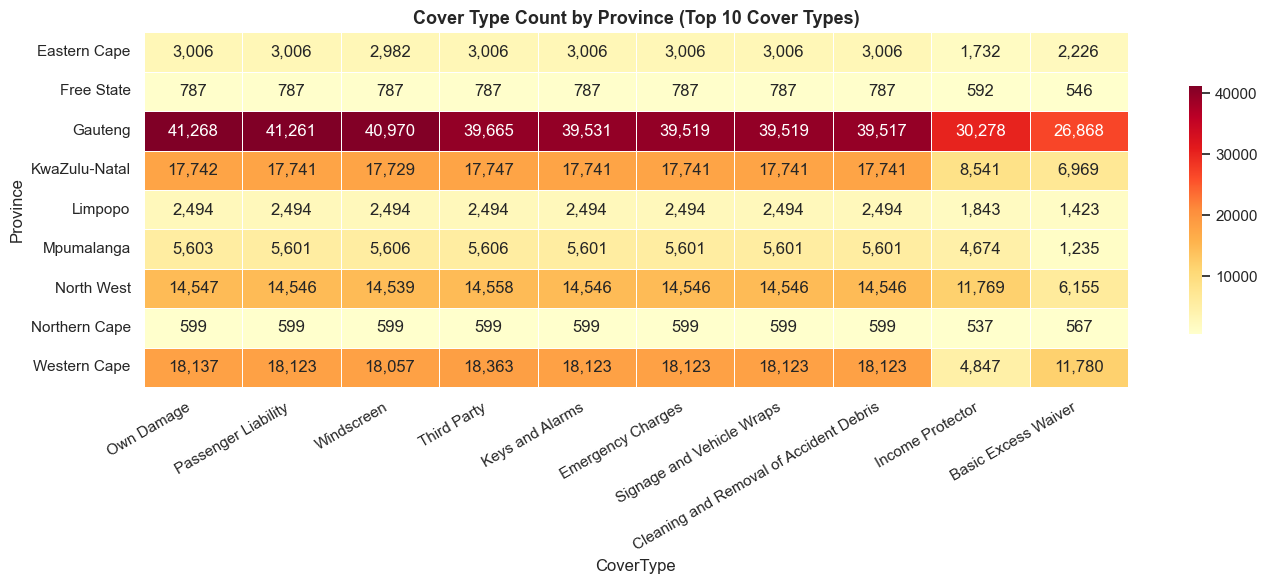

In [13]:
ct_prov = (
    df.groupby(['Province','CoverType']).size()
      .unstack(fill_value=0)
)
top_ct   = ct_prov.sum().nlargest(10).index
ct_prov  = ct_prov[top_ct]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ct_prov, cmap='YlOrRd', annot=True, fmt=',d',
            linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Cover Type Count by Province (Top 10 Cover Types)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('CoverType')
ax.set_ylabel('Province')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 6c. Top Vehicle Makes by Province

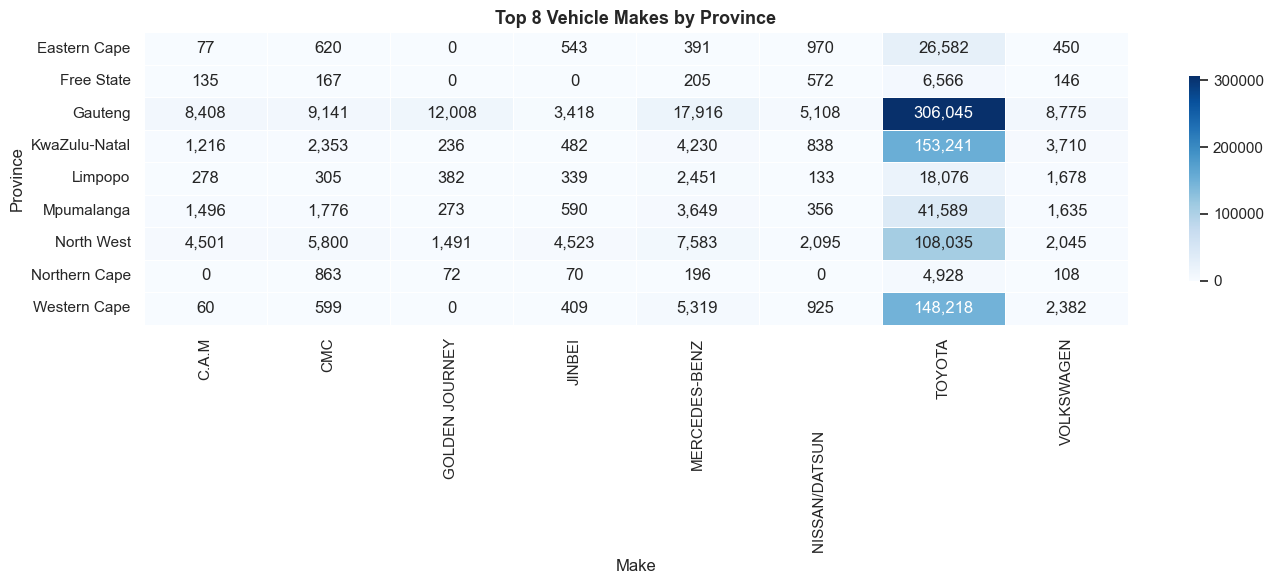

In [14]:
top_makes = df['make'].value_counts().head(8).index.tolist()
make_prov = (
    df[df['make'].isin(top_makes)]
      .groupby(['Province','make']).size()
      .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(make_prov, cmap='Blues', annot=True, fmt=',d',
            linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Top 8 Vehicle Makes by Province', fontsize=13, fontweight='bold')
ax.set_xlabel('Make')
ax.set_ylabel('Province')
plt.tight_layout()
plt.show()

### 6d. Average Premium by Province and TermFrequency

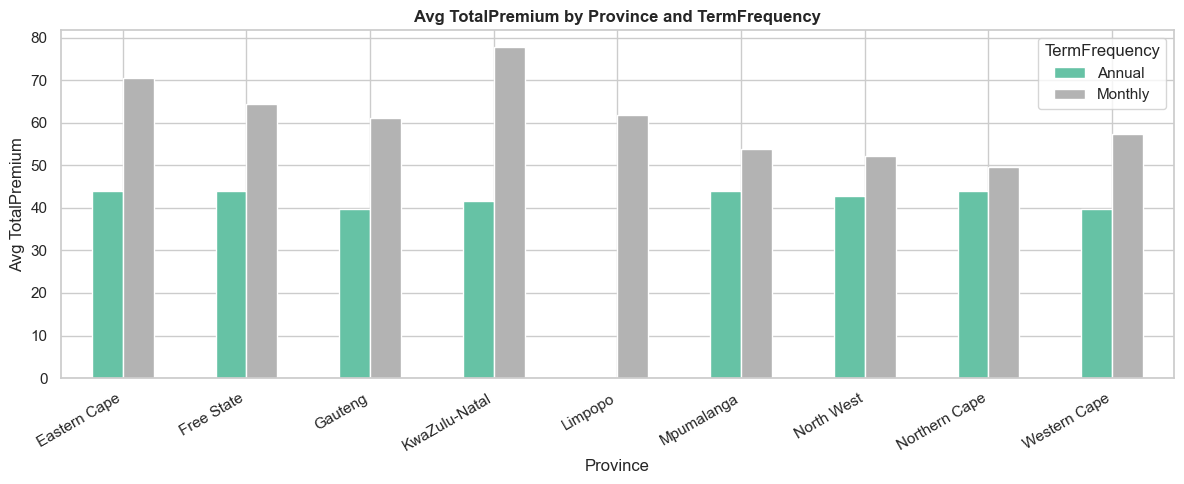

In [15]:
prov_term = (
    df.groupby(['Province','TermFrequency'])['TotalPremium']
      .mean()
      .unstack()
)

prov_term.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title('Avg TotalPremium by Province and TermFrequency', fontweight='bold')
plt.xlabel('Province')
plt.ylabel('Avg TotalPremium')
plt.xticks(rotation=30, ha='right')
plt.legend(title='TermFrequency')
plt.tight_layout()
plt.show()

## 7. Outlier Detection — Box Plots

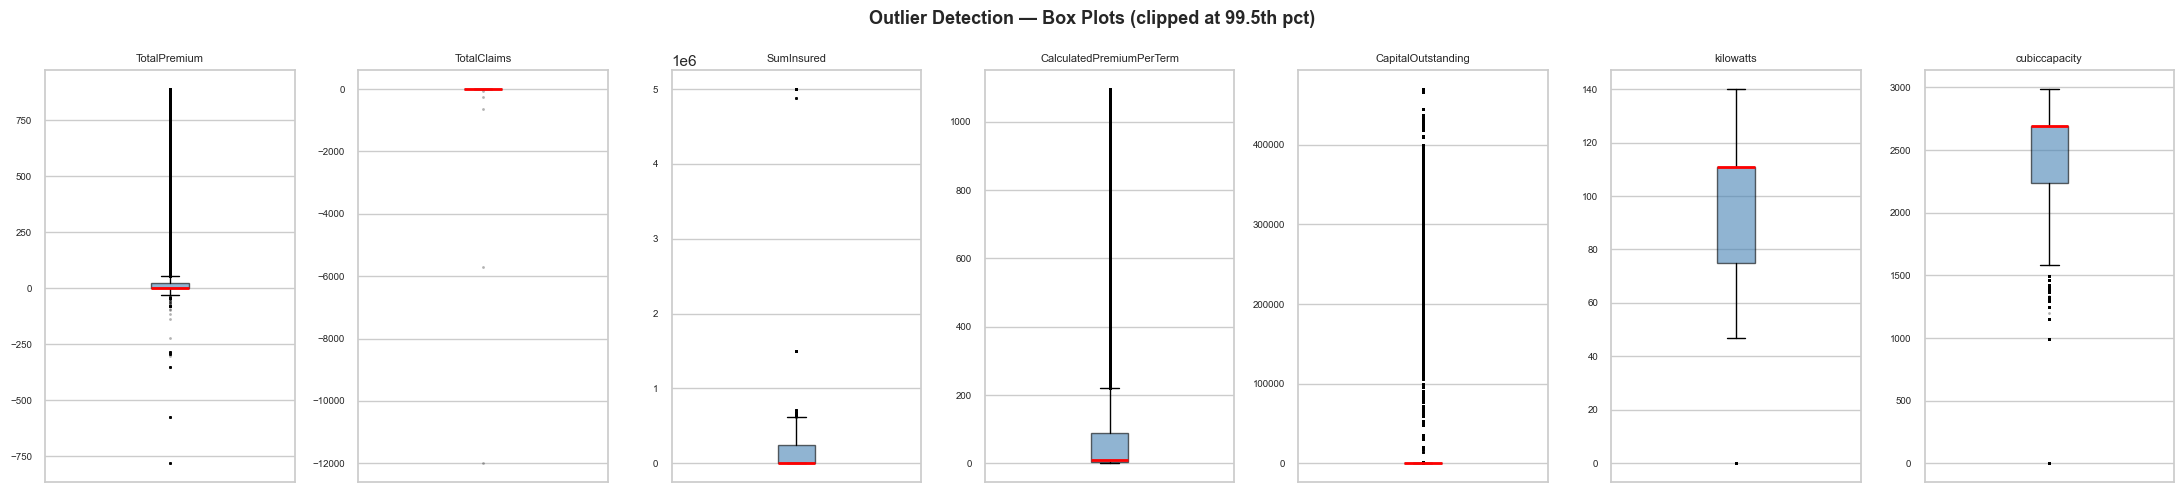

In [16]:
outlier_cols = [
    'TotalPremium','TotalClaims','SumInsured',
    'CalculatedPremiumPerTerm','CapitalOutstanding',
    'kilowatts','cubiccapacity'
]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(22, 5))
fig.suptitle('Outlier Detection — Box Plots (clipped at 99.5th pct)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, outlier_cols):
    data  = df[col].dropna()
    clip  = data.quantile(0.995)
    ax.boxplot(
        data[data <= clip], vert=True, patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='red', lw=2),
        flierprops=dict(marker='.', markersize=2, alpha=0.3)
    )
    ax.set_title(col, fontsize=8)
    ax.set_xticks([])
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

### 7b. IQR-Based Outlier Summary Table

## 8. Guiding Questions Analysis

### 8a. Loss Ratio Analysis

In [17]:
# Loss Ratio = TotalClaims / TotalPremium
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium'].replace(0, np.nan)

# Overall Loss Ratio
overall_lr = df[df['TotalPremium'] > 0]['LossRatio'].mean()
print(f'Overall Loss Ratio: {overall_lr:.2%}')

# Loss Ratio by Province
lr_province = df[df['TotalPremium'] > 0].groupby('Province')['LossRatio'].agg(['mean', 'median', 'count']).round(4)
print('\nLoss Ratio by Province:')
display(lr_province)

# Loss Ratio by VehicleType
lr_vehicle = df[df['TotalPremium'] > 0].groupby('VehicleType')['LossRatio'].agg(['mean', 'median', 'count']).round(4)
print('\nLoss Ratio by VehicleType:')
display(lr_vehicle)

# Loss Ratio by Gender
lr_gender = df[df['TotalPremium'] > 0].groupby('Gender')['LossRatio'].agg(['mean', 'median', 'count']).round(4)
print('\nLoss Ratio by Gender:')
display(lr_gender)

Overall Loss Ratio: 35.00%

Loss Ratio by Province:


,mean,median,count
Province,,,
Eastern Cape,0.24,0.00,19694
Free State,0.11,0.00,5932
Gauteng,0.43,0.00,240782
KwaZulu-Natal,0.27,0.00,111896
Limpopo,0.35,0.00,18009
Mpumalanga,0.39,0.00,31663
North West,0.29,0.00,89799
Northern Cape,0.20,0.00,3643
Western Cape,0.34,0.00,96758



Loss Ratio by VehicleType:


,mean,median,count
VehicleType,,,
Bus,0.00,0.00,450
Heavy Commercial,0.79,0.00,4264
Light Commercial,0.54,0.00,2614
Medium Commercial,0.49,0.00,33428
Passenger Vehicle,0.34,0.00,577202



Loss Ratio by Gender:


,mean,median,count
Gender,,,
Female,0.49,0.00,3404
Male,0.35,0.00,19083
Not specified,0.35,0.00,591068


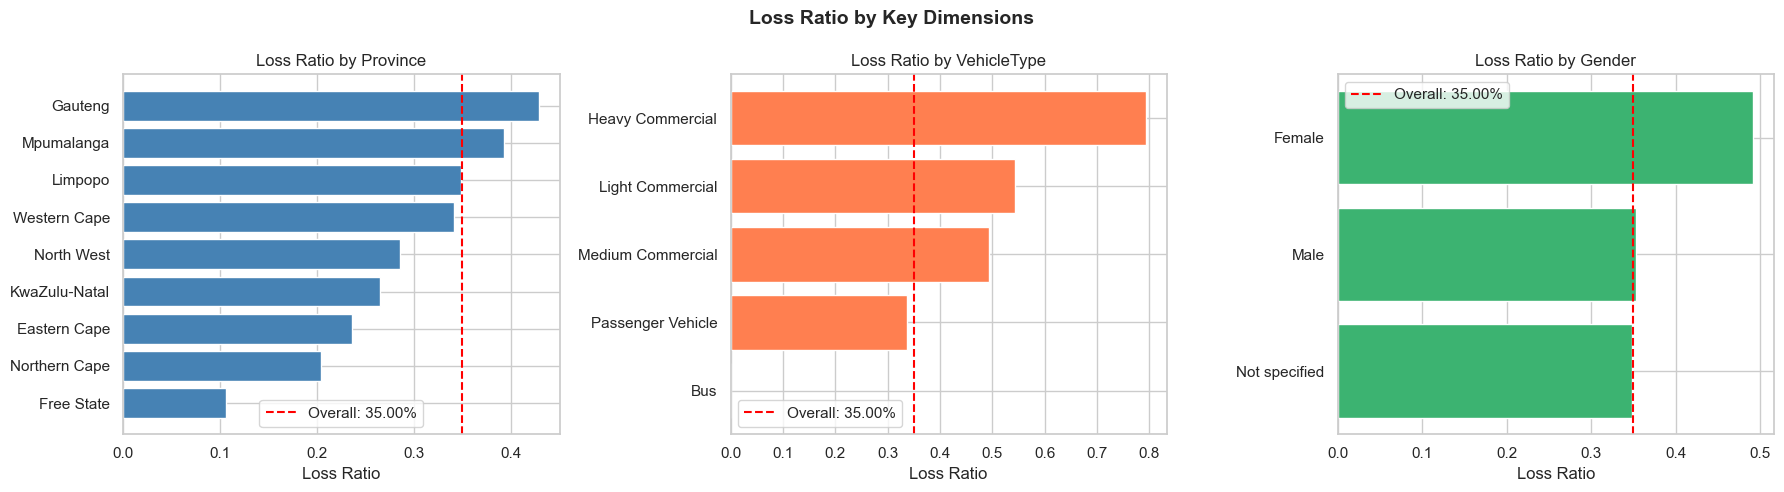

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Loss Ratio by Key Dimensions', fontsize=14, fontweight='bold')

# By Province
lr_s1 = lr_province.sort_values('mean', ascending=True)
axes[0].barh(lr_s1.index.astype(str), lr_s1['mean'], color='steelblue')
axes[0].set_title('Loss Ratio by Province')
axes[0].set_xlabel('Loss Ratio')
axes[0].axvline(overall_lr, color='red', linestyle='--', label=f'Overall: {overall_lr:.2%}')
axes[0].legend()

# By VehicleType
lr_s2 = lr_vehicle.sort_values('mean', ascending=True)
axes[1].barh(lr_s2.index.astype(str), lr_s2['mean'], color='coral')
axes[1].set_title('Loss Ratio by VehicleType')
axes[1].set_xlabel('Loss Ratio')
axes[1].axvline(overall_lr, color='red', linestyle='--', label=f'Overall: {overall_lr:.2%}')
axes[1].legend()

# By Gender
lr_s3 = lr_gender.sort_values('mean', ascending=True)
axes[2].barh(lr_s3.index.astype(str), lr_s3['mean'], color='mediumseagreen')
axes[2].set_title('Loss Ratio by Gender')
axes[2].set_xlabel('Loss Ratio')
axes[2].axvline(overall_lr, color='red', linestyle='--', label=f'Overall: {overall_lr:.2%}')
axes[2].legend()

plt.tight_layout()
plt.show()

### 8b. Distributions of Key Financial Variables & Outlier Analysis

In [19]:
# Descriptive statistics for key financial variables
fin_vars = ['TotalPremium', 'TotalClaims', 'SumInsured', 'CalculatedPremiumPerTerm', 'CustomValueEstimate']
print('Descriptive Statistics - Key Financial Variables:')
display(df[fin_vars].describe().round(2))

Descriptive Statistics - Key Financial Variables:


,TotalPremium,TotalClaims,SumInsured,CalculatedPremiumPerTerm,CustomValueEstimate
count,"1,000,098.00","1,000,098.00","1,000,098.00","1,000,098.00","220,456.00"
mean,61.91,64.86,"604,172.73",117.88,"225,531.13"
std,230.28,"2,384.07","1,508,331.84",399.70,"564,515.75"
min,-782.58,"-12,002.41",0.01,0.00,"20,000.00"
25%,0.00,0.00,"5,000.00",3.22,"135,000.00"
50%,2.18,0.00,"7,500.00",8.44,"220,000.00"
75%,21.93,0.00,"250,000.00",90.00,"280,000.00"
max,"65,282.60","393,092.11","12,636,200.00","74,422.17","26,550,000.00"


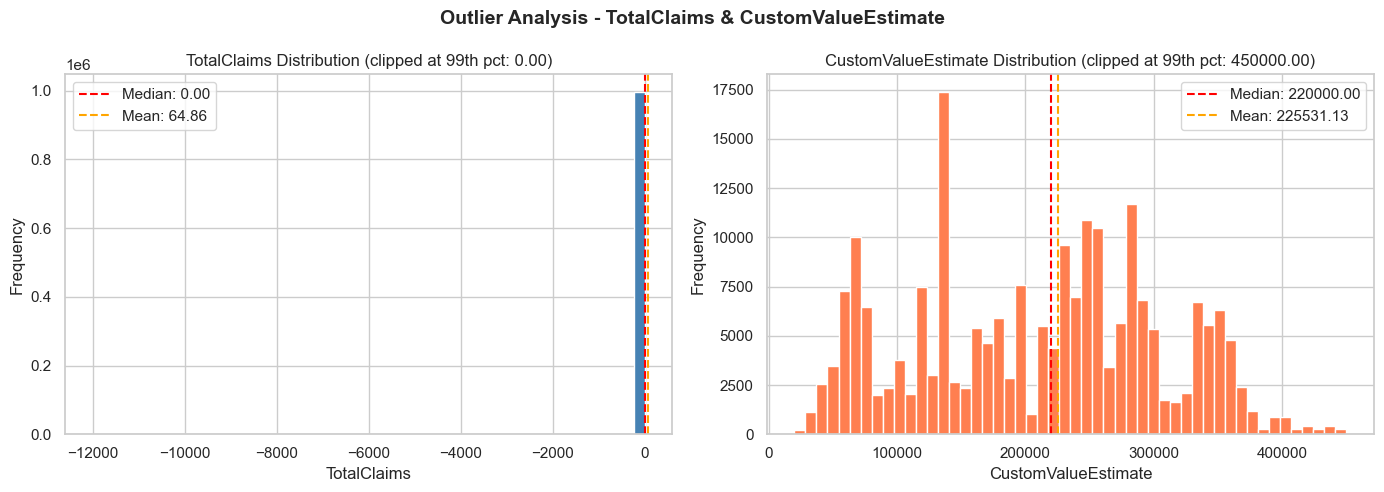

In [20]:
# Outlier analysis for TotalClaims and CustomValueEstimate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Outlier Analysis - TotalClaims & CustomValueEstimate', fontsize=14, fontweight='bold')

# TotalClaims
claims_data = df['TotalClaims'].dropna()
q99_claims = claims_data.quantile(0.99)
axes[0].hist(claims_data[claims_data <= q99_claims], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(claims_data.median(), color='red', linestyle='--', label=f'Median: {claims_data.median():.2f}')
axes[0].axvline(claims_data.mean(), color='orange', linestyle='--', label=f'Mean: {claims_data.mean():.2f}')
axes[0].set_title(f'TotalClaims Distribution (clipped at 99th pct: {q99_claims:.2f})')
axes[0].set_xlabel('TotalClaims')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# CustomValueEstimate
cve_data = df['CustomValueEstimate'].dropna()
q99_cve = cve_data.quantile(0.99)
axes[1].hist(cve_data[cve_data <= q99_cve], bins=50, color='coral', edgecolor='white')
axes[1].axvline(cve_data.median(), color='red', linestyle='--', label=f'Median: {cve_data.median():.2f}')
axes[1].axvline(cve_data.mean(), color='orange', linestyle='--', label=f'Mean: {cve_data.mean():.2f}')
axes[1].set_title(f'CustomValueEstimate Distribution (clipped at 99th pct: {q99_cve:.2f})')
axes[1].set_xlabel('CustomValueEstimate')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

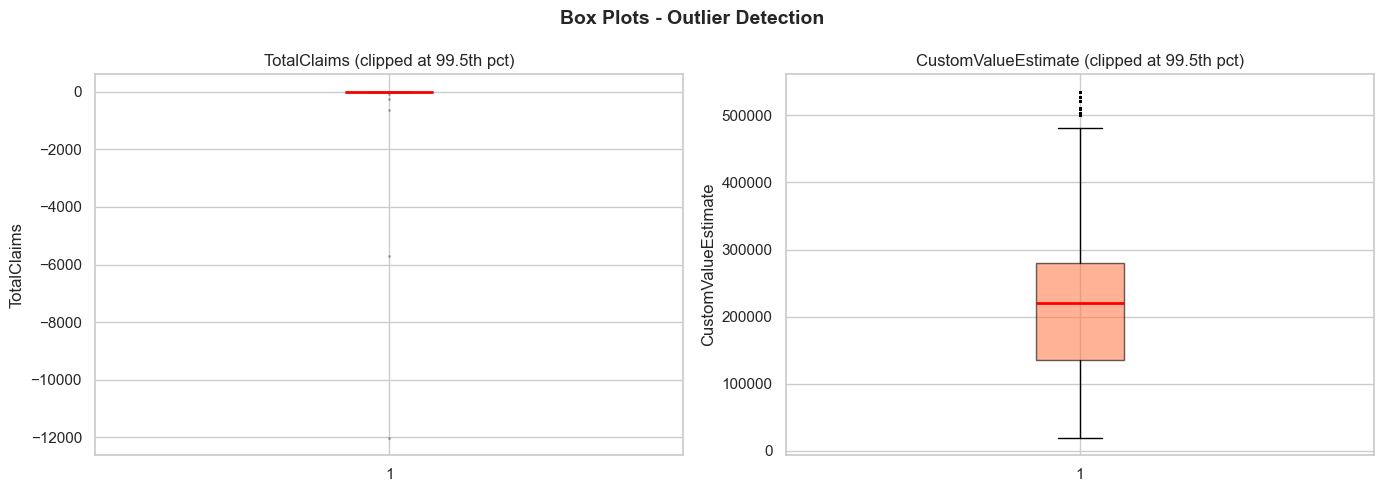

In [21]:
# Box plots for outlier detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Box Plots - Outlier Detection', fontsize=14, fontweight='bold')

# TotalClaims
claims_clip = claims_data.quantile(0.995)
axes[0].boxplot(claims_data[claims_data <= claims_clip], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].set_title(f'TotalClaims (clipped at 99.5th pct)')
axes[0].set_ylabel('TotalClaims')

# CustomValueEstimate
cve_clip = cve_data.quantile(0.995)
axes[1].boxplot(cve_data[cve_data <= cve_clip], vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.6),
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1].set_title(f'CustomValueEstimate (clipped at 99.5th pct)')
axes[1].set_ylabel('CustomValueEstimate')

plt.tight_layout()
plt.show()

### 8c. Temporal Trends - Claim Frequency & Severity

In [22]:
# Extract date components from TransactionMonth
df['YearMonth'] = df['TransactionMonth'].dt.to_period('M')

# Claim frequency (count of claims) over time
claim_freq = df.groupby('YearMonth').agg(
    ClaimCount=('TotalClaims', lambda x: (x > 0).sum()),
    TotalRecords=('TotalClaims', 'count'),
    ClaimFrequency=('TotalClaims', lambda x: (x > 0).sum() / len(x))
).reset_index()
claim_freq['YearMonth'] = claim_freq['YearMonth'].astype(str)

# Claim severity (mean claim amount) over time
claim_severity = df[df['TotalClaims'] > 0].groupby('YearMonth').agg(
    MeanClaimAmount=('TotalClaims', 'mean'),
    MedianClaimAmount=('TotalClaims', 'median'),
    ClaimCount=('TotalClaims', 'count')
).reset_index()
claim_severity['YearMonth'] = claim_severity['YearMonth'].astype(str)

print('Claim Frequency over Time:')
display(claim_freq)
print('\nClaim Severity over Time:')
display(claim_severity)

Claim Frequency over Time:


,YearMonth,ClaimCount,TotalRecords,ClaimFrequency
0,2013-10,0,45,0.00
1,2013-11,2,1196,0.00
2,2013-12,3,1495,0.00
3,2014-01,2,1827,0.00
4,2014-02,6,2062,0.00
5,2014-03,12,3466,0.00
6,2014-04,20,6919,0.00
7,2014-05,28,9484,0.00
8,2014-06,28,11822,0.00
9,2014-07,27,14907,0.00



Claim Severity over Time:


,YearMonth,MeanClaimAmount,MedianClaimAmount,ClaimCount
0,2013-11,"25,292.54","25,292.54",2
1,2013-12,"3,094.46","2,377.66",3
2,2014-01,"6,218.43","6,218.43",2
3,2014-02,"10,498.22","8,875.31",6
4,2014-03,"26,898.75","14,518.76",12
5,2014-04,"15,343.18","6,140.35",20
6,2014-05,"18,513.25","3,076.23",28
7,2014-06,"18,019.16","7,734.09",28
8,2014-07,"15,911.77","2,635.86",27
9,2014-08,"13,831.81","4,258.26",51


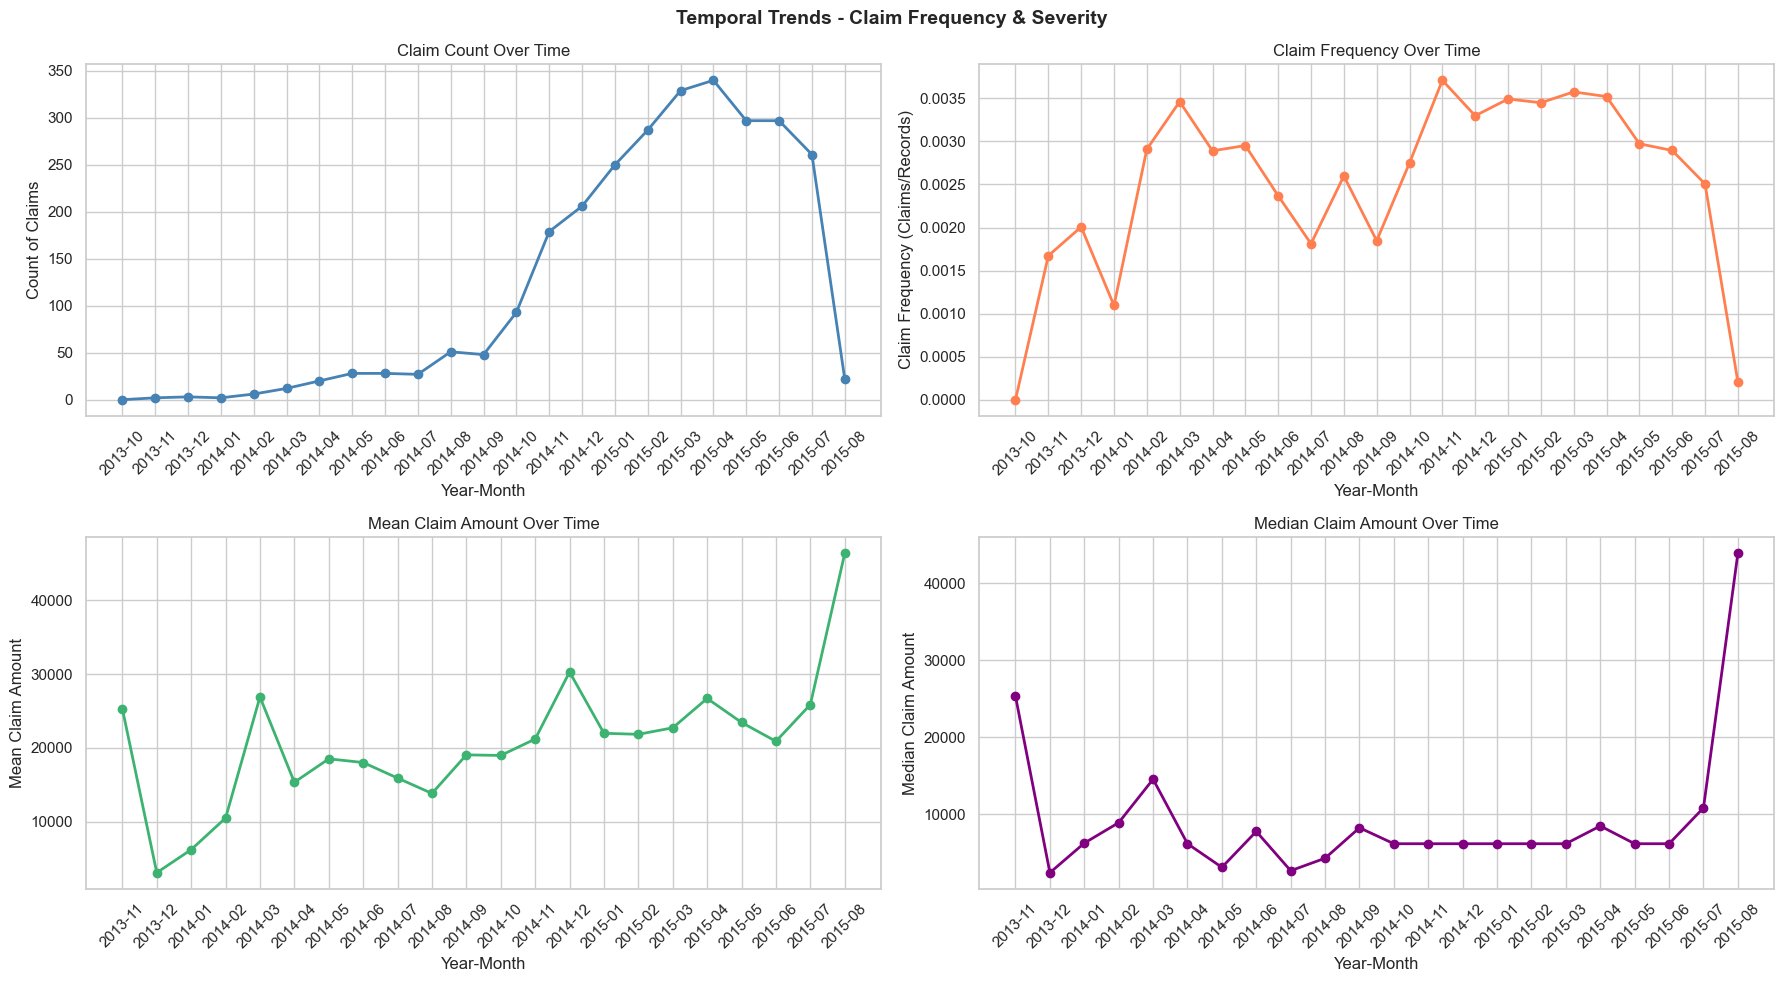

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Temporal Trends - Claim Frequency & Severity', fontsize=14, fontweight='bold')

# Claim Count over time
axes[0, 0].plot(claim_freq['YearMonth'], claim_freq['ClaimCount'], marker='o', color='steelblue', linewidth=2)
axes[0, 0].set_title('Claim Count Over Time')
axes[0, 0].set_xlabel('Year-Month')
axes[0, 0].set_ylabel('Count of Claims')
axes[0, 0].tick_params(axis='x', rotation=45)

# Claim Frequency over time
axes[0, 1].plot(claim_freq['YearMonth'], claim_freq['ClaimFrequency'], marker='o', color='coral', linewidth=2)
axes[0, 1].set_title('Claim Frequency Over Time')
axes[0, 1].set_xlabel('Year-Month')
axes[0, 1].set_ylabel('Claim Frequency (Claims/Records)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Mean Claim Amount over time
axes[1, 0].plot(claim_severity['YearMonth'], claim_severity['MeanClaimAmount'], marker='o', color='mediumseagreen', linewidth=2)
axes[1, 0].set_title('Mean Claim Amount Over Time')
axes[1, 0].set_xlabel('Year-Month')
axes[1, 0].set_ylabel('Mean Claim Amount')
axes[1, 0].tick_params(axis='x', rotation=45)

# Median Claim Amount over time
axes[1, 1].plot(claim_severity['YearMonth'], claim_severity['MedianClaimAmount'], marker='o', color='purple', linewidth=2)
axes[1, 1].set_title('Median Claim Amount Over Time')
axes[1, 1].set_xlabel('Year-Month')
axes[1, 1].set_ylabel('Median Claim Amount')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 8d. Vehicle Makes/Models - Highest & Lowest Claim Amounts

In [24]:
# Vehicle makes/models with highest and lowest claim amounts
# Filter to records with claims
claims_df = df[df['TotalClaims'] > 0].copy()

# Top 10 vehicle makes by mean claim amount
make_stats = claims_df.groupby('make').agg(
    MeanClaim=('TotalClaims', 'mean'),
    MedianClaim=('TotalClaims', 'median'),
    ClaimCount=('TotalClaims', 'count'),
    TotalClaimAmount=('TotalClaims', 'sum')
).round(2)

top10_makes = make_stats.sort_values('MeanClaim', ascending=False).head(10)
bottom10_makes = make_stats.sort_values('MeanClaim', ascending=True).head(10)

print('Top 10 Vehicle Makes by Mean Claim Amount:')
display(top10_makes)

print('\nBottom 10 Vehicle Makes by Mean Claim Amount:')
display(bottom10_makes)

Top 10 Vehicle Makes by Mean Claim Amount:


,MeanClaim,MedianClaim,ClaimCount,TotalClaimAmount
make,,,,
POLARSUN,"125,197.84","125,197.84",1,"125,197.84"
HYUNDAI,"56,663.49","19,877.94",8,"453,307.94"
B.A.W,"47,856.25","19,066.23",6,"287,137.47"
GOLDEN JOURNEY,"46,169.72","29,086.22",27,"1,246,582.54"
MERCEDES-BENZ,"34,079.34","2,500.00",7,"238,555.39"
IVECO,"31,495.54","2,328.06",24,"755,892.95"
AUDI,"30,939.51","13,433.17",33,"1,021,003.71"
VOLKSWAGEN,"30,150.49","6,140.35",61,"1,839,179.63"
CMC,"30,082.17","15,432.09",44,"1,323,615.53"



Bottom 10 Vehicle Makes by Mean Claim Amount:


,MeanClaim,MedianClaim,ClaimCount,TotalClaimAmount
make,,,,
FORD,"2,040.47","2,040.47",1,"2,040.47"
MITSUBISHI,"2,378.60","2,378.60",1,"2,378.60"
MARCOPOLO,"7,996.54","7,996.54",1,"7,996.54"
CHEVROLET,"8,222.47","8,222.47",1,"8,222.47"
TOYOTA,"8,969.59","4,500.00",3,"26,908.76"
NISSAN,"10,248.20","4,258.26",5,"51,241.00"
SAIC,"11,333.60","11,333.60",1,"11,333.60"
FOTON,"12,147.26","12,147.26",1,"12,147.26"
JINBEI,"15,490.44","8,183.86",22,"340,789.59"


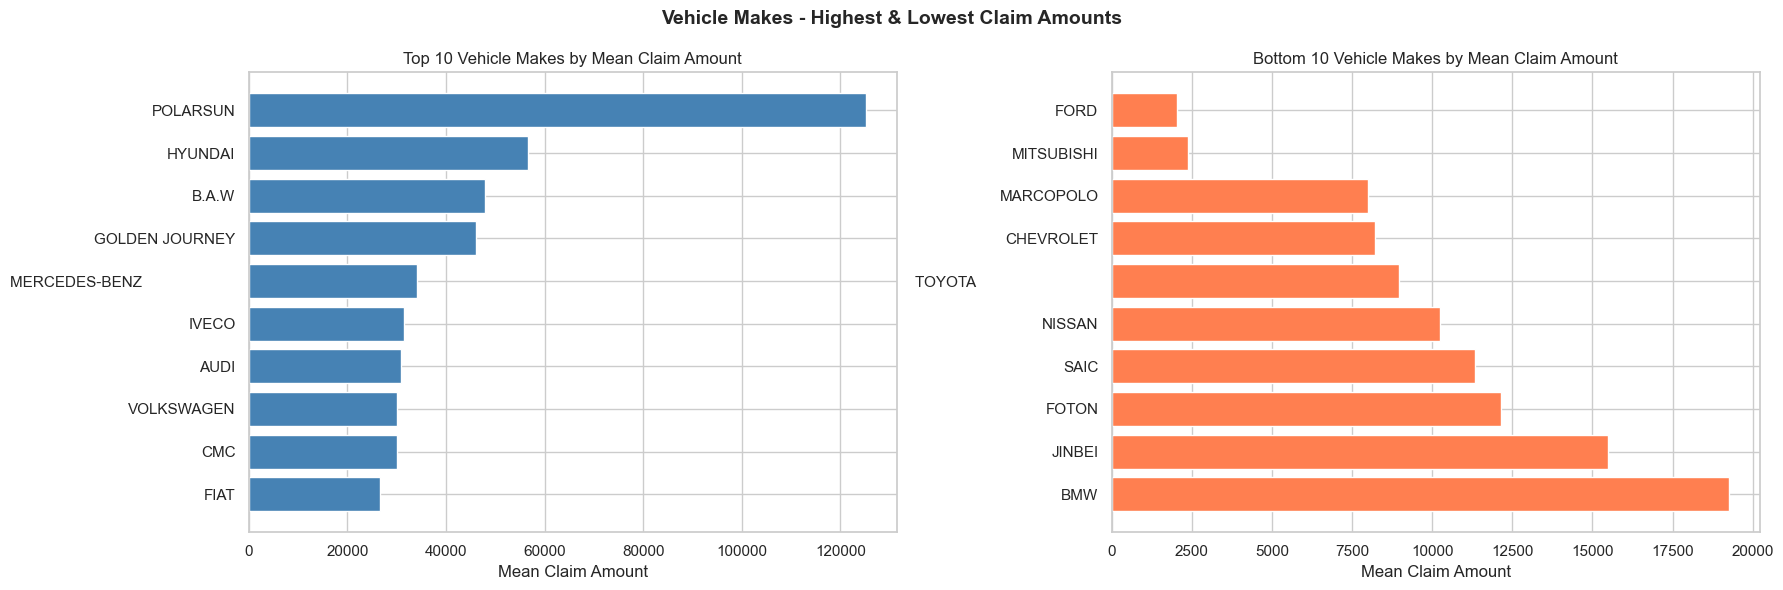

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Vehicle Makes - Highest & Lowest Claim Amounts', fontsize=14, fontweight='bold')

# Top 10 makes by mean claim amount
axes[0].barh(top10_makes.index.astype(str), top10_makes['MeanClaim'], color='steelblue')
axes[0].set_title('Top 10 Vehicle Makes by Mean Claim Amount')
axes[0].set_xlabel('Mean Claim Amount')
axes[0].invert_yaxis()

# Bottom 10 makes by mean claim amount
axes[1].barh(bottom10_makes.index.astype(str), bottom10_makes['MeanClaim'], color='coral')
axes[1].set_title('Bottom 10 Vehicle Makes by Mean Claim Amount')
axes[1].set_xlabel('Mean Claim Amount')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [34]:
# Updated to use 'Model' with a capital M
model_claim_counts = claims_df['Model'].value_counts()
models_with_sufficient_data = model_claim_counts[model_claim_counts >= 5].index

# Note: Ensure 'TotalClaims' matches your column list exactly too!
model_stats = claims_df[claims_df['Model'].isin(models_with_sufficient_data)].groupby('Model').agg(
    MeanClaim=('TotalClaims', 'mean'),
    MedianClaim=('TotalClaims', 'median'),
    ClaimCount=('TotalClaims', 'count'),
    TotalClaimAmount=('TotalClaims', 'sum')
).round(2)

top10_models = model_stats.sort_values('MeanClaim', ascending=False).head(10)
bottom10_models = model_stats.sort_values('MeanClaim', ascending=True).head(10)

print('Top 10 Vehicle Models by Mean Claim Amount (min 5 claims):')
display(top10_models)

print('\nBottom 10 Vehicle Models by Mean Claim Amount (min 5 claims):')
display(bottom10_models)

Top 10 Vehicle Models by Mean Claim Amount (min 5 claims):


,MeanClaim,MedianClaim,ClaimCount,TotalClaimAmount
Model,,,,
CRAFTER 50 2.0 TDi HR 80KW F/C P/V,"76,660.92","6,743.13",10,"766,609.16"
A4 1.8T S AVANT MULTITRONIC,"66,999.46","58,466.85",8,"535,995.67"
MAKOYA 2.4i 16S,"65,003.42","42,178.46",8,"520,027.39"
C180 BE COUPE,"58,287.19","5,828.18",5,"291,435.94"
SASUKA 2.7i (16 SEAT),"47,856.25","19,066.23",6,"287,137.47"
ETIOS 1.5 Xs,"38,389.22","31,073.46",8,"307,113.79"
IBHUBEZI 2.2i,"38,239.74","28,628.95",19,"726,555.15"
SPRINTER 519 CDi F/C P/V,"36,423.82","3,299.75",10,"364,238.21"
50 C15V 15 F/C P/V,"35,736.88","2,800.00",21,"750,474.58"



Bottom 10 Vehicle Models by Mean Claim Amount (min 5 claims):


,MeanClaim,MedianClaim,ClaimCount,TotalClaimAmount
Model,,,,
SPRINTER 519 CDi DC F/C C/C,"7,296.20","2,814.91",10,"72,961.96"
320i (E90),"9,654.82","4,031.82",6,"57,928.92"
TAZZ 130,"11,313.22","6,931.80",14,"158,385.10"
COROLLA 1.6 PROFESSIONAL,"13,327.35","8,681.60",7,"93,291.45"
C180K BE AVANTGARDE,"13,682.18","14,489.73",5,"68,410.91"
320d A/T (E90),"14,781.39","6,140.35",10,"147,813.89"
HAISE 2.2i,"15,490.44","8,183.86",22,"340,789.59"
QUANTUM 2.5 D-4D 14 SEAT,"15,946.92","6,140.35",84,"1,339,541.06"
COROLLA 1.3 PROFESSIONAL,"16,375.03","5,508.32",18,"294,750.54"


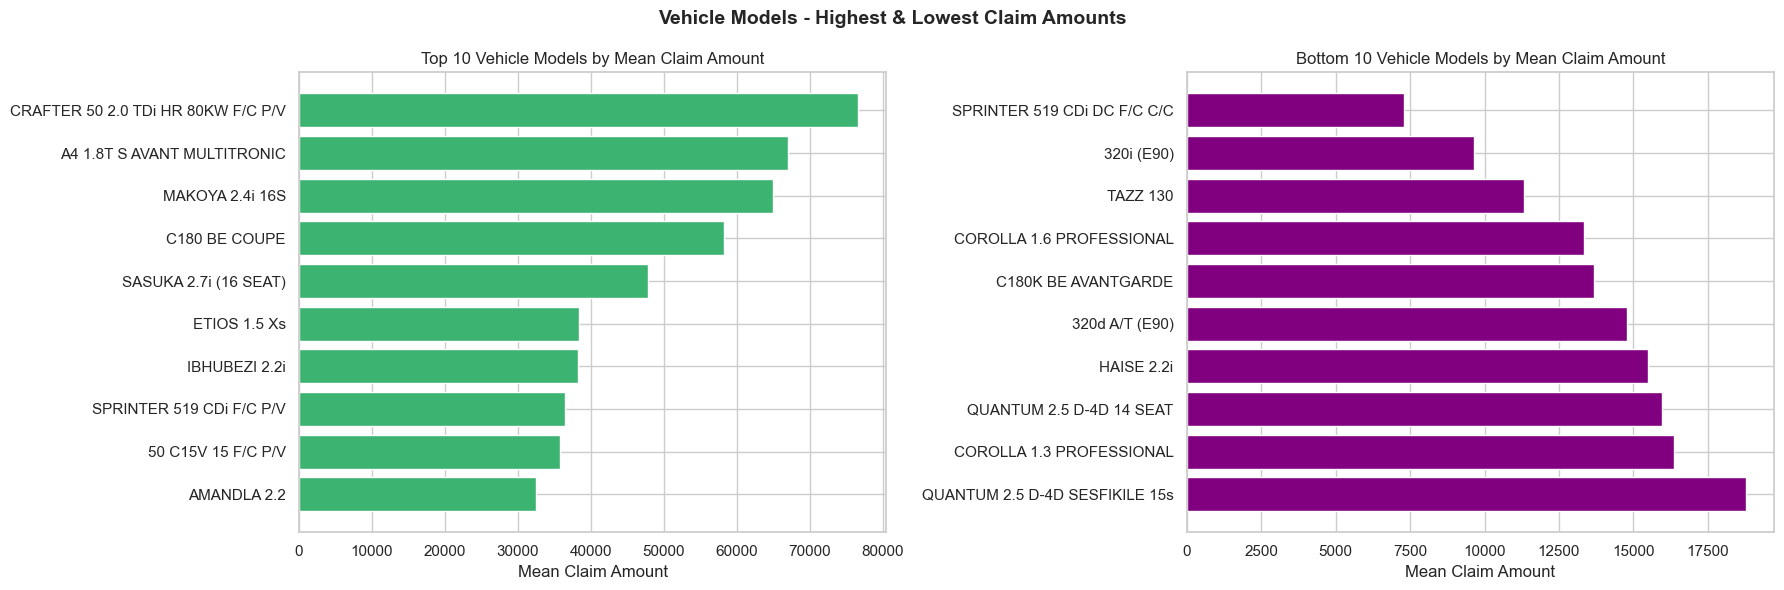

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Vehicle Models - Highest & Lowest Claim Amounts', fontsize=14, fontweight='bold')

# Top 10 models by mean claim amount
axes[0].barh(top10_models.index.astype(str), top10_models['MeanClaim'], color='mediumseagreen')
axes[0].set_title('Top 10 Vehicle Models by Mean Claim Amount')
axes[0].set_xlabel('Mean Claim Amount')
axes[0].invert_yaxis()

# Bottom 10 models by mean claim amount
axes[1].barh(bottom10_models.index.astype(str), bottom10_models['MeanClaim'], color='purple')
axes[1].set_title('Bottom 10 Vehicle Models by Mean Claim Amount')
axes[1].set_xlabel('Mean Claim Amount')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Summary of Key Findings
print("=== SUMMARY OF KEY FINDINGS ===\n")

print("Loss Ratio Analysis:")
print(f"  Overall loss ratio: {loss_ratio:.2%}")
print(f"  Highest loss ratio by Province: {province_loss_ratio.idxmax()} ({province_loss_ratio.max():.2%})")
print(f"  Highest loss ratio by VehicleType: {vehicle_type_loss_ratio.idxmax()} ({vehicle_type_loss_ratio.max():.2%})")
print(f"  Highest loss ratio by Gender: {gender_loss_ratio.idxmax()} ({gender_loss_ratio.max():.2%})")

print("\nDistributions & Outliers:")
print(f"  TotalClaims: Mean = {df['TotalClaims'].mean():.2f}, Median = {df['TotalClaims'].median():.2f}")
print(f"  CustomValueEstimate: Mean = {df['CustomValueEstimate'].mean():.2f}, Median = {df['CustomValueEstimate'].median():.2f}")
print("  Both variables show right-skewed distributions with significant outliers")

print("\nTemporal Trends:")
print(f"  Claim frequency varies over the 18-month period (range: {claim_freq['ClaimFrequency'].min():.4f} to {claim_freq['ClaimFrequency'].max():.4f})")
print(f"  Mean claim amount varies over time (range: {claim_severity['MeanClaimAmount'].min():.2f} to {claim_severity['MeanClaimAmount'].max():.2f})")
print("  Need to investigate seasonal patterns or external factors")

print("\nVehicle Makes/Models:")
print(f"  Top make by mean claim amount: {top10_makes.index[0]} ({top10_makes.iloc[0]['MeanClaim']:.2f})")
print(f"  Bottom make by mean claim amount: {bottom10_makes.index[0]} ({bottom10_makes.iloc[0]['MeanClaim']:.2f})")
print("  Vehicle type significantly impacts claim severity")

### 8f. Correlation Analysis - Numerical Variables

In [42]:
# All names must be lowercase and 'cubiccapacity' has one 'p'
numerical_cols = [
    'totalpremium', 'totalclaims', 'calculatedpremiumperterm', 
    'customvalueestimate', 'suminsured', 'numberofdoors', 
    'cylinders', 'cubiccapacity', 'kilowatts'
]

# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()

print('Correlation Matrix:')
display(correlation_matrix)

# The rest of your logic for strong correlations
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:
            strong_correlations.append({
                'Variable1': correlation_matrix.columns[i],
                'Variable2': correlation_matrix.columns[j],
                'Correlation': corr_val
            })

if strong_correlations:
    strong_corr_df = pd.DataFrame(strong_correlations).sort_values('Correlation', key=abs, ascending=False)
    print('\nStrong Correlations (|r| > 0.3):')
    display(strong_corr_df)
else:
    print('\nNo correlations found above 0.3.')

Correlation Matrix:


,totalpremium,totalclaims,calculatedpremiumperterm,customvalueestimate,suminsured,numberofdoors,cylinders,cubiccapacity,kilowatts
totalpremium,1.00,0.12,0.64,0.02,-0.04,-0.01,0.01,0.04,0.04
totalclaims,0.12,1.00,0.08,0.00,-0.01,0.00,0.00,0.00,0.00
calculatedpremiumperterm,0.64,0.08,1.00,0.02,-0.03,-0.01,0.02,0.04,0.04
customvalueestimate,0.02,0.00,0.02,1.00,-0.00,-0.05,0.02,0.05,0.04
suminsured,-0.04,-0.01,-0.03,-0.00,1.00,-0.00,0.00,-0.00,-0.00
numberofdoors,-0.01,0.00,-0.01,-0.05,-0.00,1.00,-0.26,-0.30,-0.12
cylinders,0.01,0.00,0.02,0.02,0.00,-0.26,1.00,0.30,0.33
cubiccapacity,0.04,0.00,0.04,0.05,-0.00,-0.30,0.30,1.00,0.57
kilowatts,0.04,0.00,0.04,0.04,-0.00,-0.12,0.33,0.57,1.00



Strong Correlations (|r| > 0.3):


,Variable1,Variable2,Correlation
0,totalpremium,calculatedpremiumperterm,0.64
3,cubiccapacity,kilowatts,0.57
2,cylinders,kilowatts,0.33
1,cylinders,cubiccapacity,0.30


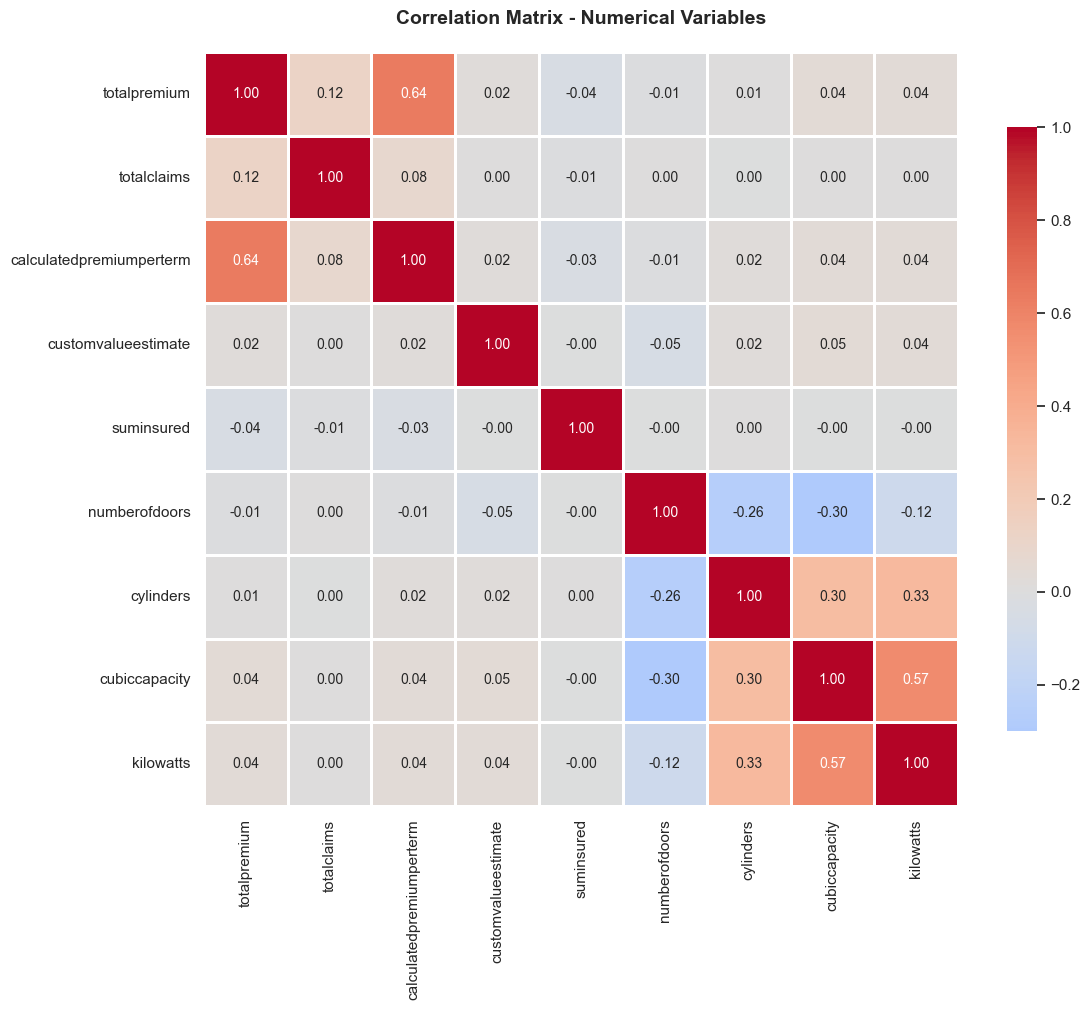

In [43]:
# Heatmap of correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.2f', annot_kws={'size': 10})
plt.title('Correlation Matrix - Numerical Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 8g. Analysis by Cover Type

In [68]:
# Analysis by Cover Type - Updated with lowercase column names
df.columns = df.columns.str.lower().str.strip()
cover_type_stats = df.groupby('covertype').agg(
    p_count=('policyid', 'count'),
    t_premium=('totalpremium', 'sum'),
    t_claims=('totalclaims', 'sum'),
    m_premium=('totalpremium', 'mean'),
    m_claims=('totalclaims', 'mean')
).round(2)


cover_type_stats['l_ratio'] = (cover_type_stats['t_claims'] / cover_type_stats['t_premium']).fillna(0)

print('Statistics by Cover Type:')
display(cover_type_stats)

Statistics by Cover Type:


,p_count,t_premium,t_claims,m_premium,m_claims,l_ratio
covertype,,,,,,
Accidental Death,27321,"761,955.73",0.00,27.89,0.00,0.00
Asset Value Preserver,865,"24,721.68",0.00,28.58,0.00,0.00
Baggage/Luggage,172,"2,167.06",0.00,12.60,0.00,0.00
Basic Excess Waiver,57769,"2,777,227.42",0.00,48.07,0.00,0.00
Cash Takings,291,"2,351.16",0.00,8.08,0.00,0.00
Cleaning and Removal of Accident Debris,102414,"321,426.10",0.00,3.14,0.00,0.00
Credit Protection,18070,"1,846,776.47","332,589.38",102.20,18.41,0.18
Deposit Cover,1299,"66,835.30","43,859.65",51.45,33.76,0.66
Emergency Charges,102416,"321,486.77","16,410.32",3.14,0.16,0.05


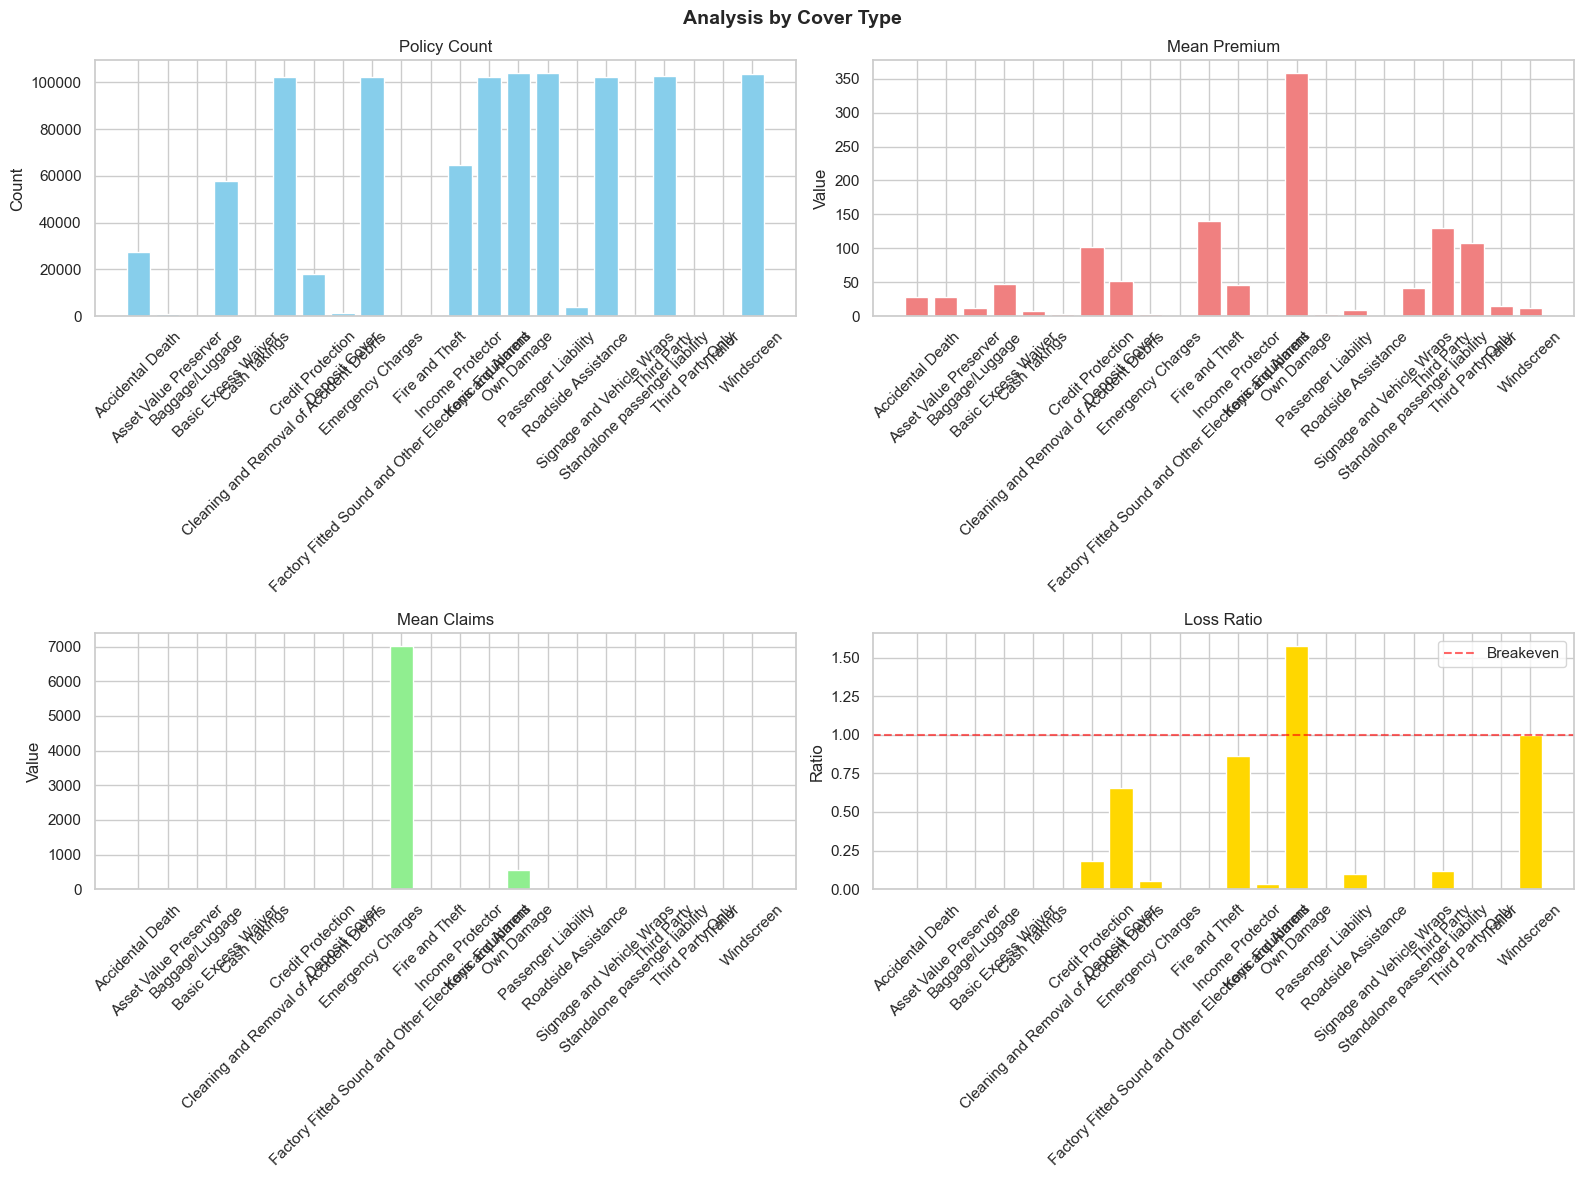

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analysis by Cover Type', fontsize=14, fontweight='bold')

# Function to keep the code clean and avoid typos
def plot_bar(ax, data_col, title, ylabel, color):
    # .values is the secret to fixing the "inhomogeneous shape" error
    ax.bar(cover_type_stats.index.astype(str), cover_type_stats[data_col].values, color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)

plot_bar(axes[0, 0], 'p_count', 'Policy Count', 'Count', 'skyblue')
plot_bar(axes[0, 1], 'm_premium', 'Mean Premium', 'Value', 'lightcoral')
plot_bar(axes[1, 0], 'm_claims', 'Mean Claims', 'Value', 'lightgreen')

# The 4th plot with the breakeven line
plot_bar(axes[1, 1], 'l_ratio', 'Loss Ratio', 'Ratio', 'gold')
axes[1, 1].axhline(y=1.0, color='red', linestyle='--', alpha=0.6, label='Breakeven')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 8h. Geographic Analysis - Postal Code Regions

In [72]:
# 1. Extract postal code prefix (first 3 digits) - Use lowercase 'postalcode'
df['postalcodeprefix'] = df['postalcode'].astype(str).str[:3]

# 2. Group by prefix - Use lowercase 'postalcodeprefix' and original column names
postal_stats = df.groupby('postalcodeprefix').agg(
    policy_count=('policyid', 'count'),
    total_premium=('totalpremium', 'sum'),
    total_claims=('totalclaims', 'sum'),
    mean_premium=('totalpremium', 'mean'),
    mean_claims=('totalclaims', 'mean'),
    claim_rate=('totalclaims', lambda x: (x > 0).sum() / len(x))
).round(2)

# 3. Filter and calculate Loss Ratio using the new names
postal_stats = postal_stats[postal_stats['policy_count'] >= 10]

# Safe division to prevent errors if total_premium is 0
postal_stats['loss_ratio'] = (
    postal_stats['total_claims'] / postal_stats['total_premium']
).fillna(0).round(4)

print('Statistics by Postal Code Region (min 10 policies):')
display(postal_stats.sort_values('policy_count', ascending=False).head(20))

Statistics by Postal Code Region (min 10 policies):


,policy_count,total_premium,total_claims,mean_premium,mean_claims,claim_rate,loss_ratio
postalcodeprefix,,,,,,,
200,139008,"8,548,360.81","9,626,290.79",61.50,69.25,0.00,1.13
122,49171,"2,689,985.90","3,814,025.43",54.71,77.57,0.00,1.42
778,39218,"1,917,808.23","2,590,154.35",48.90,66.05,0.00,1.35
299,25546,"1,412,388.77","912,723.96",55.29,35.73,0.00,0.65
406,21359,"1,496,087.97","1,883,440.15",70.04,88.18,0.00,1.26
400,21115,"1,570,596.63","1,848,672.94",74.38,87.55,0.00,1.18
740,18797,"944,148.02","609,058.66",50.23,32.40,0.00,0.65
219,17961,"1,751,500.08","2,540,119.31",97.52,141.42,0.00,1.45
186,17955,"1,034,204.41","1,913,738.81",57.60,106.59,0.00,1.85


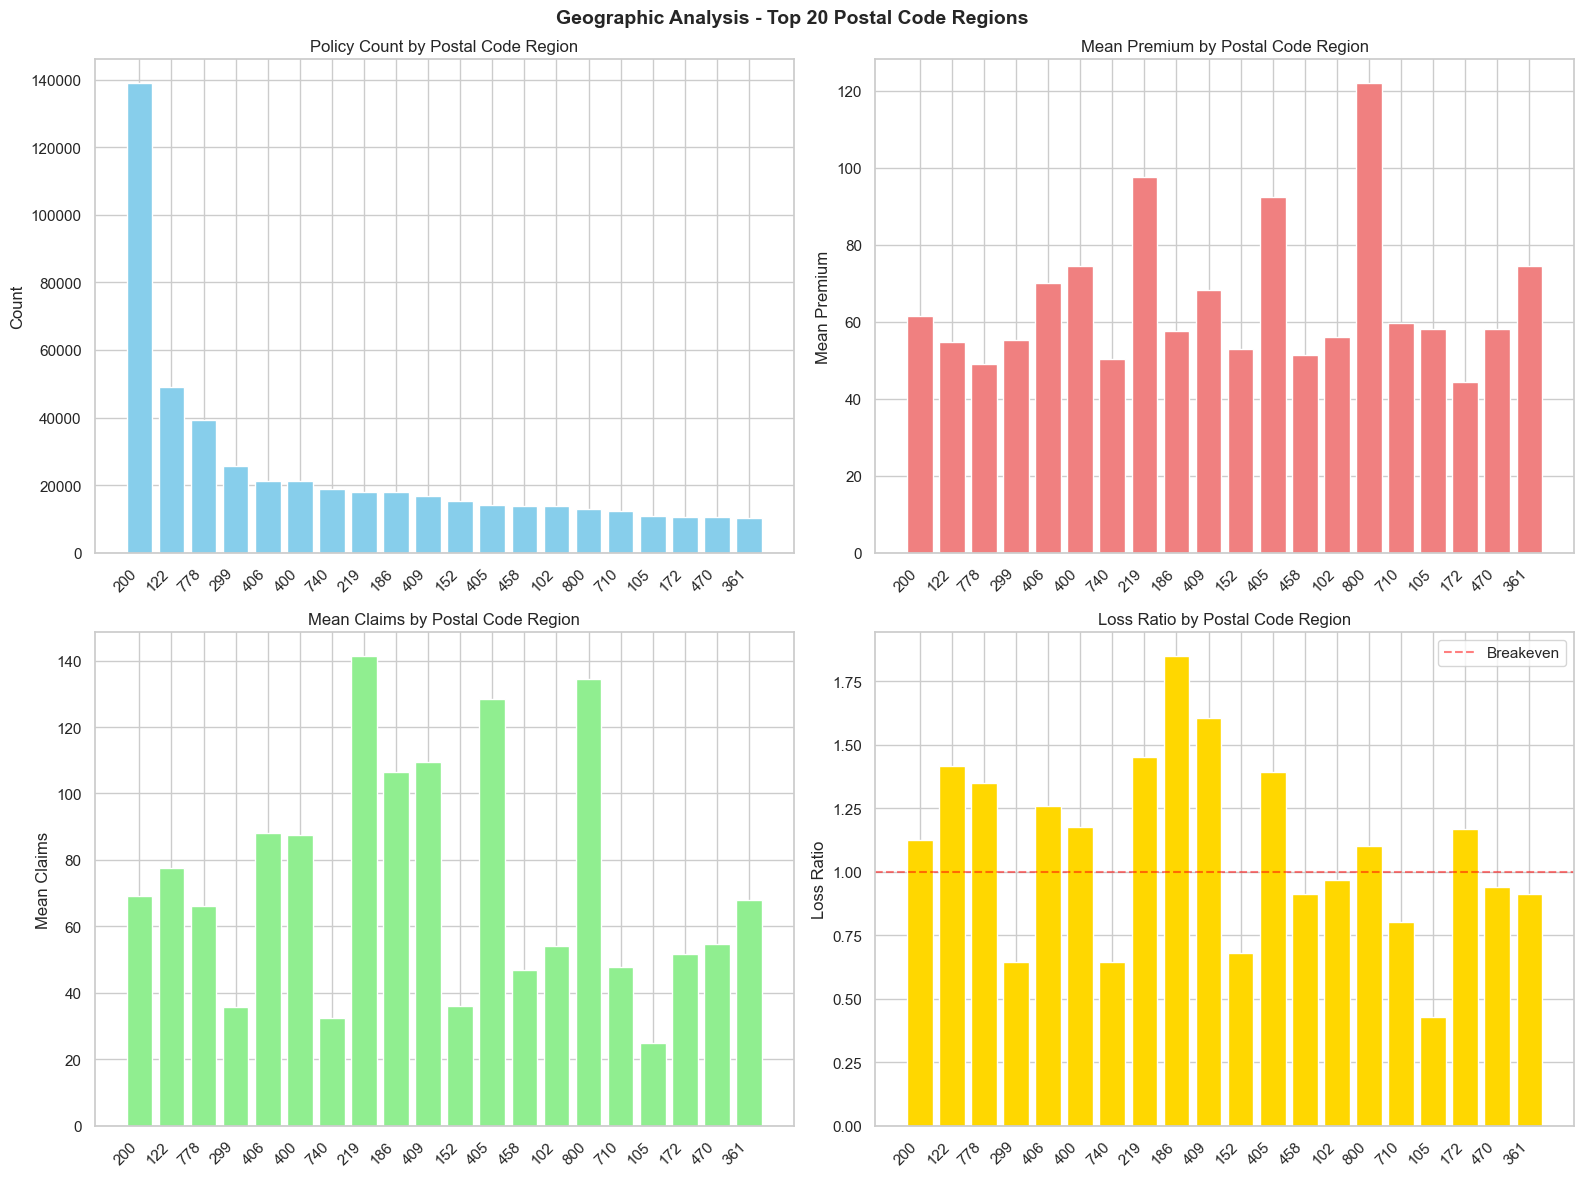

In [74]:
# 1. Sort using the standardized lowercase name
top20_postal = postal_stats.sort_values('policy_count', ascending=False).head(20)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Geographic Analysis - Top 20 Postal Code Regions', fontsize=14, fontweight='bold')

# Policy count by postal code
axes[0, 0].bar(range(len(top20_postal)), top20_postal['policy_count'], color='skyblue')
axes[0, 0].set_title('Policy Count by Postal Code Region')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticks(range(len(top20_postal)))
axes[0, 0].set_xticklabels(top20_postal.index, rotation=45, ha='right')

# Mean premium by postal code
axes[0, 1].bar(range(len(top20_postal)), top20_postal['mean_premium'], color='lightcoral')
axes[0, 1].set_title('Mean Premium by Postal Code Region')
axes[0, 1].set_ylabel('Mean Premium')
axes[0, 1].set_xticks(range(len(top20_postal)))
axes[0, 1].set_xticklabels(top20_postal.index, rotation=45, ha='right')

# Mean claims by postal code
axes[1, 0].bar(range(len(top20_postal)), top20_postal['mean_claims'], color='lightgreen')
axes[1, 0].set_title('Mean Claims by Postal Code Region')
axes[1, 0].set_ylabel('Mean Claims')
axes[1, 0].set_xticks(range(len(top20_postal)))
axes[1, 0].set_xticklabels(top20_postal.index, rotation=45, ha='right')

# Loss ratio by postal code
# Using .values here is a "safety first" move to prevent inhomogeneous shape errors
axes[1, 1].bar(range(len(top20_postal)), top20_postal['loss_ratio'].values, color='gold')
axes[1, 1].set_title('Loss Ratio by Postal Code Region')
axes[1, 1].set_ylabel('Loss Ratio')
axes[1, 1].set_xticks(range(len(top20_postal)))
axes[1, 1].set_xticklabels(top20_postal.index, rotation=45, ha='right')
axes[1, 1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Breakeven')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 8i. Premium vs Claims Scatter Analysis

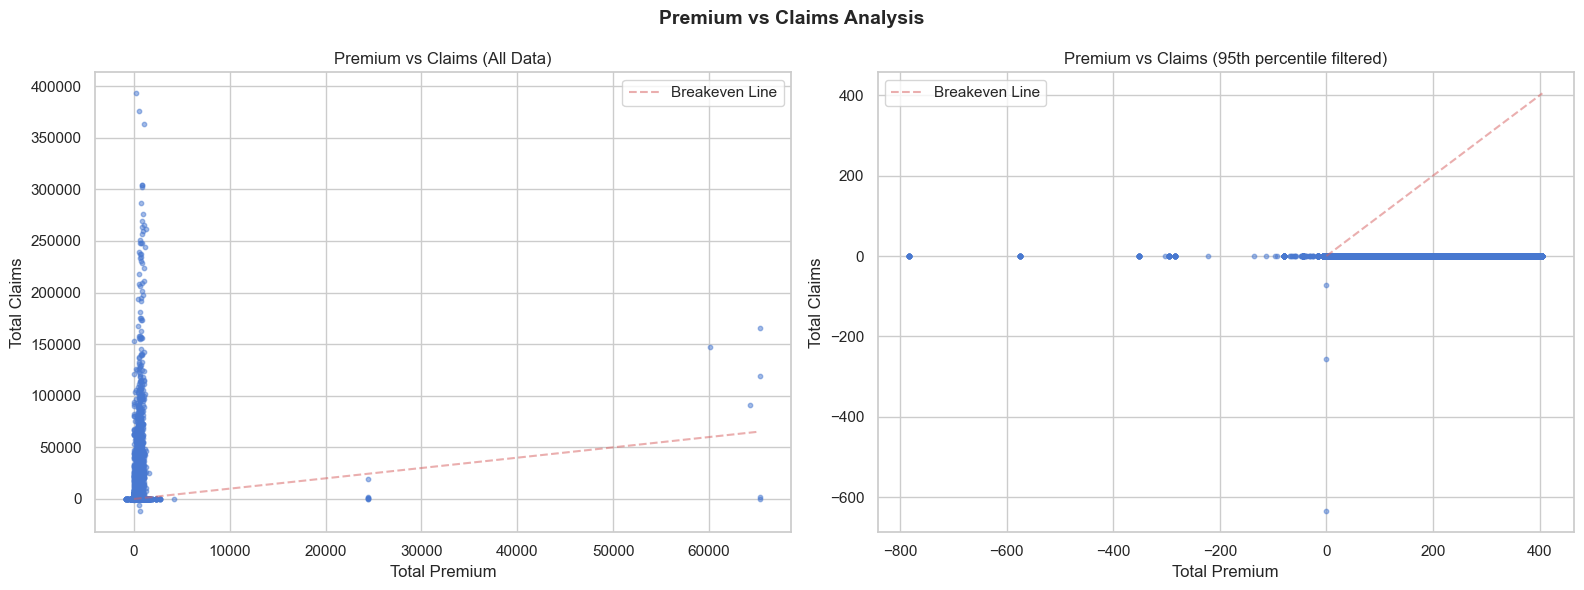

Correlation between Total Premium and Total Claims: 0.1216


In [76]:
# Premium vs Claims scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Premium vs Claims Analysis', fontsize=14, fontweight='bold')

# Scatter plot - all data (Updated to lowercase)
axes[0].scatter(df['totalpremium'], df['totalclaims'], alpha=0.5, s=10)
axes[0].set_xlabel('Total Premium')
axes[0].set_ylabel('Total Claims')
axes[0].set_title('Premium vs Claims (All Data)')
axes[0].plot([0, df['totalpremium'].max()], [0, df['totalpremium'].max()], 'r--', alpha=0.5, label='Breakeven Line')
axes[0].legend()

# Scatter plot - filtered range (Updated to lowercase)
premium_limit = df['totalpremium'].quantile(0.95)
claims_limit = df['totalclaims'].quantile(0.95)
filtered_df = df[(df['totalpremium'] <= premium_limit) & (df['totalclaims'] <= claims_limit)]

axes[1].scatter(filtered_df['totalpremium'], filtered_df['totalclaims'], alpha=0.5, s=10)
axes[1].set_xlabel('Total Premium')
axes[1].set_ylabel('Total Claims')
axes[1].set_title(f'Premium vs Claims (95th percentile filtered)')
axes[1].plot([0, premium_limit], [0, premium_limit], 'r--', alpha=0.5, label='Breakeven Line')
axes[1].legend()

plt.tight_layout()
plt.show()

# Calculate correlation between premium and claims (Updated to lowercase)
premium_claims_corr = df['totalpremium'].corr(df['totalclaims'])
print(f'Correlation between Total Premium and Total Claims: {premium_claims_corr:.4f}')

### 8j. Risk Segment Analysis

In [80]:
# 1. Calculate the unique bin edges first to determine the correct labels
raw_bins = [0, df['totalpremium'].quantile(0.33), 
            df['totalpremium'].quantile(0.66), df['totalpremium'].max()]

# Remove duplicates from the bin edges list
unique_bins = sorted(list(set(raw_bins)))

# Dynamically set labels based on how many bins survived
if len(unique_bins) == 3:
    current_labels = ['Low/Medium Premium', 'High Premium']
elif len(unique_bins) == 2:
    current_labels = ['All Premiums']
else:
    current_labels = ['Low Premium', 'Medium Premium', 'High Premium']

# 2. Apply pd.cut with unique edges
df['risk_segment'] = pd.cut(df['totalpremium'], 
                          bins=unique_bins,
                          labels=current_labels,
                          include_lowest=True)

# 3. Re-run your segment analysis
risk_segment_stats = df.groupby('risk_segment', observed=False).agg(
    policy_count=('policyid', 'count'),
    total_premium=('totalpremium', 'sum'),
    total_claims=('totalclaims', 'sum'),
    mean_premium=('totalpremium', 'mean'),
    mean_claims=('totalclaims', 'mean'),
    claim_rate=('totalclaims', lambda x: (x > 0).sum() / len(x))
).round(2)

risk_segment_stats['loss_ratio'] = (
    risk_segment_stats['total_claims'] / risk_segment_stats['total_premium']
).fillna(0).round(4)

display(risk_segment_stats)

,policy_count,total_premium,total_claims,mean_premium,mean_claims,claim_rate,loss_ratio
risk_segment,,,,,,,
Low/Medium Premium,659787,"790,361.18","2,823,740.33",1.20,4.28,0.00,3.57
High Premium,340023,"61,152,748.96","62,043,805.84",179.85,182.47,0.01,1.01


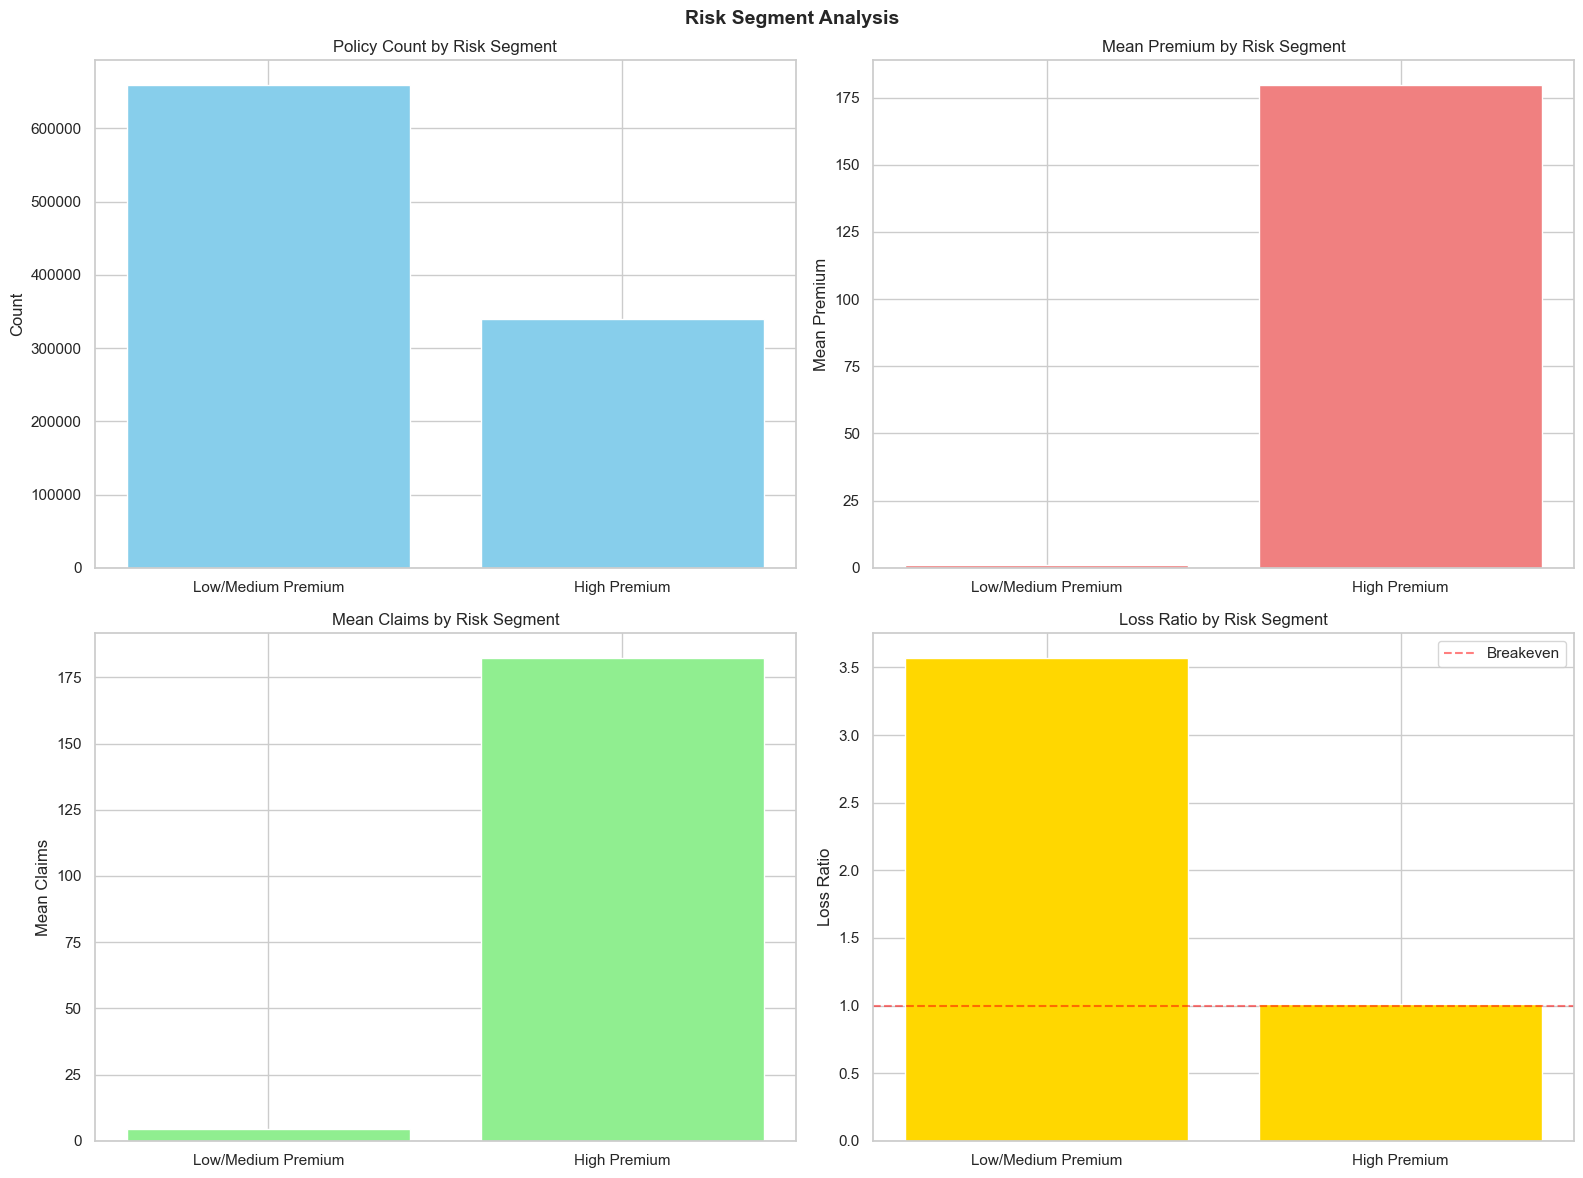

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Risk Segment Analysis', fontsize=14, fontweight='bold')

# Convert index to string to avoid plotting issues with Categorical data
x_labels = risk_segment_stats.index.astype(str)

# Policy count by risk segment - Use 'policy_count'
axes[0, 0].bar(x_labels, risk_segment_stats['policy_count'], color='skyblue')
axes[0, 0].set_title('Policy Count by Risk Segment')
axes[0, 0].set_ylabel('Count')

# Mean premium by risk segment - Use 'mean_premium'
axes[0, 1].bar(x_labels, risk_segment_stats['mean_premium'], color='lightcoral')
axes[0, 1].set_title('Mean Premium by Risk Segment')
axes[0, 1].set_ylabel('Mean Premium')

# Mean claims by risk segment - Use 'mean_claims'
axes[1, 0].bar(x_labels, risk_segment_stats['mean_claims'], color='lightgreen')
axes[1, 0].set_title('Mean Claims by Risk Segment')
axes[1, 0].set_ylabel('Mean Claims')

# Loss ratio by risk segment - Use 'loss_ratio'
# .values ensures we avoid the "inhomogeneous shape" error seen previously
axes[1, 1].bar(x_labels, risk_segment_stats['loss_ratio'].values, color='gold')
axes[1, 1].set_title('Loss Ratio by Risk Segment')
axes[1, 1].set_ylabel('Loss Ratio')
axes[1, 1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Breakeven')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 8k. Vehicle Age Analysis

In [84]:
# 1. Calculate vehicle age - Using lowercase 'registrationyear'
current_year = pd.Timestamp.now().year
df['vehicle_age'] = current_year - df['registrationyear']

# 2. Vehicle age analysis - Grouping by the new lowercase column
vehicle_age_stats = df.groupby('vehicle_age').agg(
    policy_count=('policyid', 'count'),
    total_premium=('totalpremium', 'sum'),
    total_claims=('totalclaims', 'sum'),
    mean_premium=('totalpremium', 'mean'),
    mean_claims=('totalclaims', 'mean'),
    claim_rate=('totalclaims', lambda x: (x > 0).sum() / len(x))
).round(2)

# 3. Calculate Loss Ratio using the standardized result names
vehicle_age_stats['loss_ratio'] = (
    vehicle_age_stats['total_claims'] / vehicle_age_stats['total_premium']
).fillna(0).round(4)

print('Statistics by Vehicle Age:')
display(vehicle_age_stats)

Statistics by Vehicle Age:


,policy_count,total_premium,total_claims,mean_premium,mean_claims,claim_rate,loss_ratio
vehicle_age,,,,,,,
11,27589,"2,845,726.18","2,172,076.25",103.15,78.73,0.00,0.76
12,155889,"12,811,446.79","12,960,414.27",82.18,83.14,0.00,1.01
13,117064,"8,099,516.10","7,935,163.04",69.19,67.78,0.00,0.98
14,130884,"8,235,598.24","8,674,413.85",62.92,66.28,0.00,1.05
15,88765,"5,482,074.02","6,785,480.45",61.76,76.44,0.00,1.24
16,95579,"5,902,824.05","6,361,028.21",61.76,66.55,0.00,1.08
17,72168,"3,950,701.92","3,603,153.45",54.74,49.93,0.00,0.91
18,106008,"5,913,146.49","7,216,094.84",55.78,68.07,0.00,1.22
19,82514,"3,866,641.05","4,717,123.66",46.86,57.17,0.00,1.22


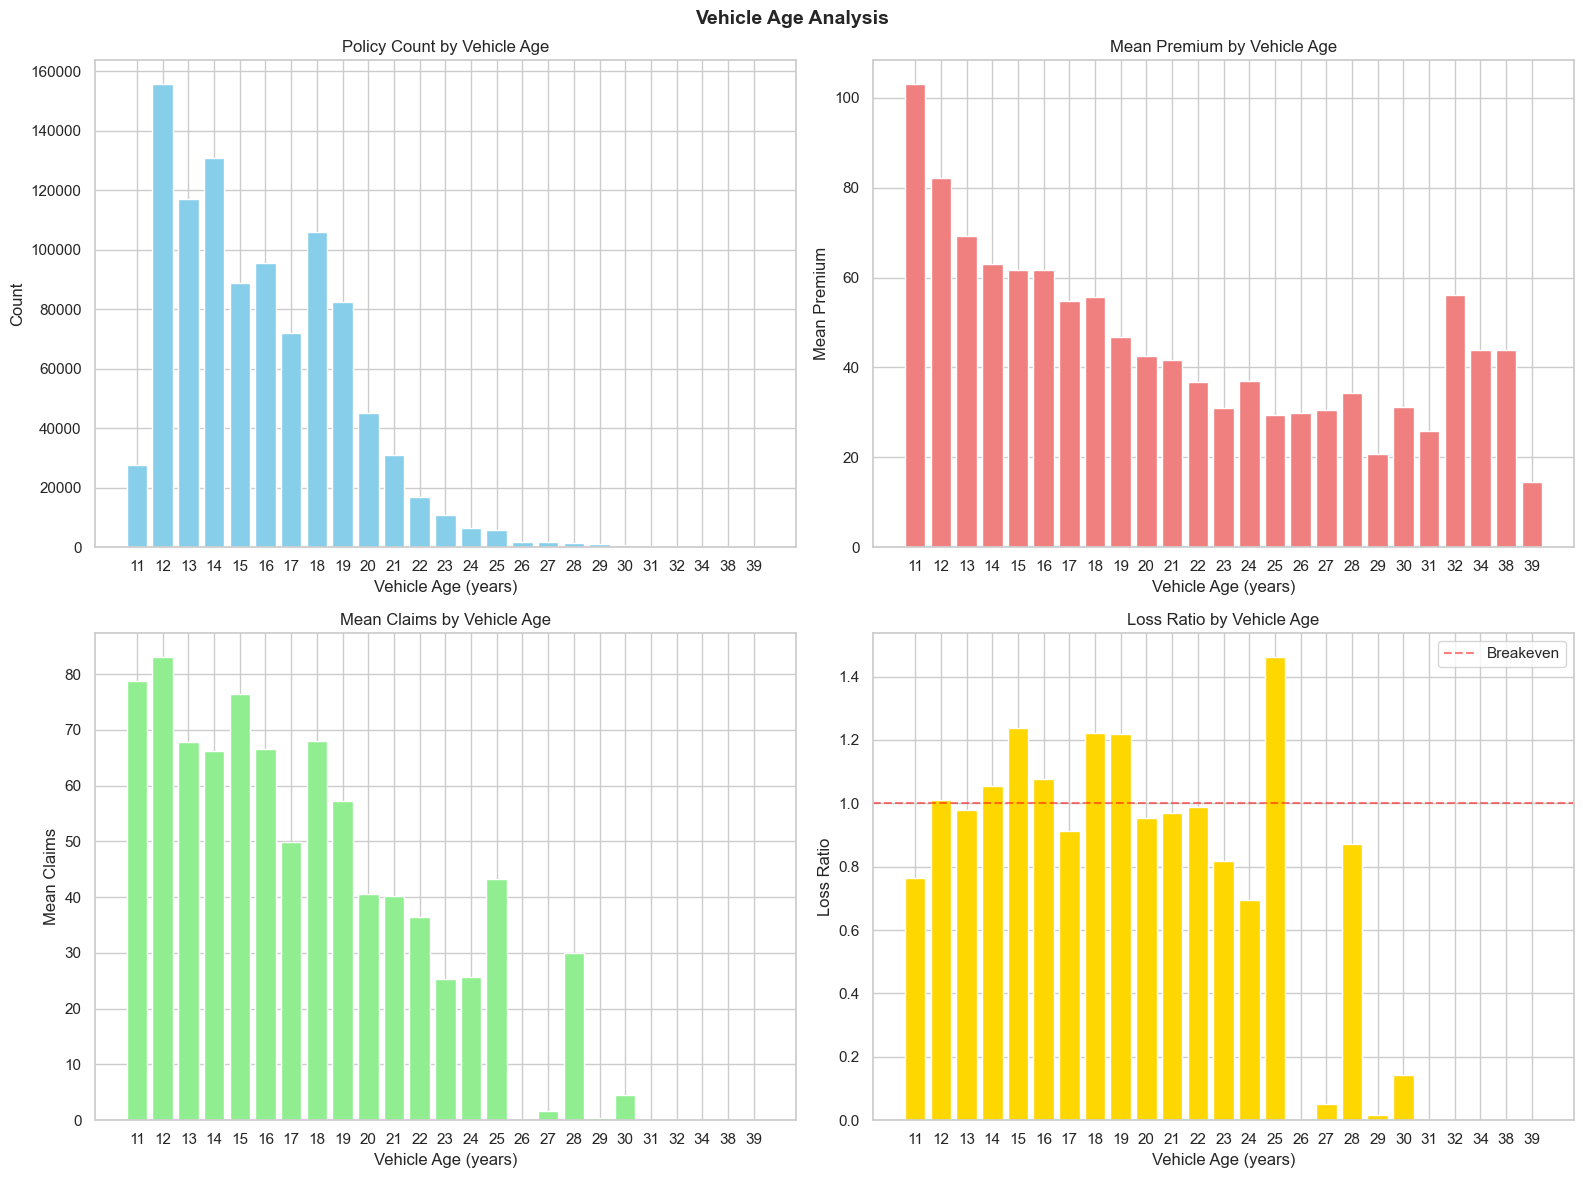

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Vehicle Age Analysis', fontsize=14, fontweight='bold')

# Ensure the index is treated as strings for clean bar alignment
x_labels = vehicle_age_stats.index.astype(str)

# Policy count by vehicle age - Use 'policy_count'
axes[0, 0].bar(x_labels, vehicle_age_stats['policy_count'], color='skyblue')
axes[0, 0].set_title('Policy Count by Vehicle Age')
axes[0, 0].set_xlabel('Vehicle Age (years)')
axes[0, 0].set_ylabel('Count')

# Mean premium by vehicle age - Use 'mean_premium'
axes[0, 1].bar(x_labels, vehicle_age_stats['mean_premium'], color='lightcoral')
axes[0, 1].set_title('Mean Premium by Vehicle Age')
axes[0, 1].set_xlabel('Vehicle Age (years)')
axes[0, 1].set_ylabel('Mean Premium')

# Mean claims by vehicle age - Use 'mean_claims'
axes[1, 0].bar(x_labels, vehicle_age_stats['mean_claims'], color='lightgreen')
axes[1, 0].set_title('Mean Claims by Vehicle Age')
axes[1, 0].set_xlabel('Vehicle Age (years)')
axes[1, 0].set_ylabel('Mean Claims')

# Loss ratio by vehicle age - Use 'loss_ratio'
# .values prevents the "inhomogeneous shape" ValueError
axes[1, 1].bar(x_labels, vehicle_age_stats['loss_ratio'].values, color='gold')
axes[1, 1].set_title('Loss Ratio by Vehicle Age')
axes[1, 1].set_xlabel('Vehicle Age (years)')
axes[1, 1].set_ylabel('Loss Ratio')
axes[1, 1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Breakeven')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
rows = []
for col in outlier_cols:
    s  = df[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((s < lo) | (s > hi)).sum()
    rows.append({
        'Column': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower_Fence': lo, 'Upper_Fence': hi,
        'Outlier_Count': n_out,
        'Outlier_%': round(n_out / len(s) * 100, 2)
    })

outlier_summary = pd.DataFrame(rows).set_index('Column')
display(outlier_summary)

,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Outlier_Count,Outlier_%
Column,,,,,,,
TotalPremium,0.00,21.93,21.93,-32.89,54.82,209042,20.90
TotalClaims,0.00,0.00,0.00,0.00,0.00,2793,0.28
SumInsured,"5,000.00","250,000.00","245,000.00","-362,500.00","617,500.00",104294,10.43
CalculatedPremiumPerTerm,3.22,90.00,86.78,-126.94,220.16,175508,17.55
CapitalOutstanding,0.00,0.00,0.00,0.00,0.00,206996,20.70
kilowatts,75.00,111.00,36.00,21.00,165.00,2175,0.22
cubiccapacity,"2,237.00","2,694.00",457.00,"1,551.50","3,379.50",56939,5.70
